In [1]:
import os
import pickle
import sys
from itertools import chain, combinations
from time import time

import matplotlib.pyplot as plt
import pandas as pd
import pyro
import pyro.distributions as dist
import seaborn as sns
import torch
from chirho.interventional.handlers import do
from chirho.observational.handlers import condition
from IPython.display import Image, display
from loguru import logger

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler
from pci.tools.find_root import find_repo_root

# Smoke-test mode is triggered by ``CI=1``. It runs the notebook end-to-end on
# a tiny problem budget so the full pipeline (exact + approximate benchmarks
# + plots) executes without kairos and without the cached results from a real
# run. The non-smoke settings reproduce the figures shown in the paper.
smoke_test = "CI" in os.environ

root = find_repo_root()
results_dir = os.path.join(root, "docs/source/ac_benchmark")
os.makedirs(results_dir, exist_ok=True)

print(f"Results will be saved to {results_dir}")

logger.remove()
logger.add(sys.stderr, level="INFO" if smoke_test else "DEBUG")


if smoke_test:
    # Sample sizes are deliberately offset from `num_worlds_at_site` so the
    # `broadcast_mask` heuristic in `condition_on_interventional_regime`
    # picks the sampling axis unambiguously.
    runtime_limit = 0.05  # 3 s per benchmark run
    num_worlds_at_site = 3
    initial_samples_small = 8
    initial_samples_large = 16
else:
    runtime_limit = 60  # minutes
    num_worlds_at_site = 10
    initial_samples_small = 250
    initial_samples_large = 500

runtime_limit_seconds = runtime_limit * 60

# change to True to force a fresh run; smoke tests always run fresh
fresh_run = True if smoke_test else False


Results will be saved to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark


**Table of contents**<a id='toc0_'></a>    
- [Overview](#toc1_)    
  - [Motivations](#toc1_1_)    
  - [Generalized throwing problem](#toc1_2_)    
  - [Explicit actual cause computations](#toc1_3_)    
  - [Approximate estimation using `SearchForExplanation`](#toc1_4_)    
  - [Benchmarking setup](#toc1_5_)    
  - [Benchmarking results](#toc1_6_)    
  - [Limitations](#toc1_7_)    
- [Code](#toc2_)    
  - [The scaled throwing model](#toc2_1_)    
  - [Exact actual causality computations](#toc2_2_)    
    - [One pair of sites, all cases where c=1](#toc2_2_1_)    
    - [Two pairs of sites where c=1](#toc2_2_2_)    
    - [General application to increasing numbers of sites](#toc2_2_3_)    
  - [Approximate computations with `SearchForExplanation`](#toc2_3_)    
    - [Searchable model](#toc2_3_1_)    
    - [Conditioning on interventions](#toc2_3_2_)    
    - [General application to increasing number of sites](#toc2_3_3_)    
  - [Inspect results](#toc2_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_'></a>[Overview](#toc0_)



### <a id='toc1_1_'></a>[Motivations](#toc0_)

A standard minimally interesting example used in the discussion of actual causality uses categorical variables: Sally and Billy pick up stones and throw them at a bottle. Sally’s stone gets there first, shattering the bottle. Both throws are perfectly accurate, so Billy’s stone would have shattered the bottle had it not been preempted by Sally’s throw. The intuition is that Sally's throw is responsible for the shattering, but not so Billy's. However, it is false that had Sally not thrown the stone, the bottle would not have shattered, so the simple counterfactual condition fails, which motivates the search for a better definition of responsibility attribution.

In this case study, we "mutliply" the structure underlying the classical bottle-throwing example with the goal to evaluate the extent to which the exact actual causality computation can handle it, and the extent and performance of the approximate estimation methods that use `SearchForExplanation`.

### <a id='toc1_2_'></a>[Generalized throwing problem](#toc0_)


For a problem size $n$, we define the corresponding deterministic model in which there will be $n$ "copies" of "Sally throwing" events $A_i$ and and $n$ copies of "Bill throwing" events, $B_i$, $i = 1, \dots n$. For each pair $A_i, B_i$ we mimick the overdetermination and undercutting in the same fashion they played out in the original example: $B_i$ succeeds only if $B_i$ throws and $A_i$ doesn't. The final outcome $C$ is triggered if at each $i$ we have a hit, i.e. either $A_i$ or $B_i$. This gives a scalable challenge akin to the original one. 

In other words, we consider binary variables   $A_1,\dots,A_n, B_1,\dots,B_n \in \{0,1\}$ 
where $A_i$ represents Sally’s $i$-th throw and $B_i$ represents Billy’s $i$-th throw.

For each pair $(A_i, B_i)$, we introduce endogenous variables $W^a_i, W^b_i \in \{0,1\}$ indicating whether $A_i$ ($B_i$) hit the target, ie. for each $i = 1,\dots,n$,
$$
W^a_i = A_i \,\,\,\,\, W^b_i = (B_i \land \lnot A_i).
$$

The final bottle-shattering outcome $C$ occurs iff every pair produces a hit:
$$
C = \bigwedge_{i=1}^n \left( W^a_i \vee W^b_i\right).
$$



The model also allows us to analytically compute responsibility indicators $R_i$ during a forward pass for evaluation purposes:

$$
R_i =
\begin{cases}
1, & \text{if } W^a_i = 1,\\[4pt]
2, & \text{if } W^b_i = 1,\\[4pt]
0, & \text{otherwise}.
\end{cases}
$$

### <a id='toc1_3_'></a>[Explicit actual cause computations](#toc0_)

First, we implement the original explicit actual causality calculation. Given a particular probelm size and a particular input values, the procedure attempts to decide which variables are responsible as follows:

1. consider all possible subsets of all cause candidates,
2. consider all possible witness sets (subsets of all witness candidates),
3. for each subset of the former looking for an existential necessity claim witness among the latter. 

We incorporate factivity, by only considering input settings that result in $C=1$, and minimality requirements, by dropping cause subsets which are not subset-minimal. Features deemed responsible are those and only those that end up in a minimal identified subset.

### <a id='toc1_4_'></a>[Approximate estimation using `SearchForExplanation`](#toc0_)

The approximate method evaluation, in contrast, uses the following Monte Carlo inference algorithm. Note that the definitions we gave in the body of the paper are separable from and do not force some of the inference method choices we made and could be replaced with other inference methods, at user's decision.

1. It starts with some sampling distribution for the suspect and witness activation. It follows the sampling pattern parametrized by $n_s$ and $n_w$, the maximum number of suspects simultaneously considered, and the maximum number of context elements dropped. It then samples uniformly an integer $k_s$ ($k_w$) between 1 and $n_s$ ($n_k$) and then samples $k_n$ antecedents to be intervened and $k_w$ witnesses to be dropped from the context. In some runs we use $n_a = n_w = 4$, in one we allow full subset sampling by ensuring $n_a = n_w \geq$ (the number of atecedents $+$ the number of suspects).
2. Given an input, in a forward run we collect all factual variables and compute the analytic solution.
3. For each active witness we intervene with the factual value in both necessity and sufficiency worlds.
4. For each active antecedent, we sample alternative values from a distribution resulting from excising the current model's distribution to avoid factual values (in fact, in this simple set up, this boils down to inverting Boolean values, but we keep the explicit sampling procedure to be more critical of the algorithm). We intervene with the alternative values in the necessity world and the factual values in the sufficiency world.
5. In fact, as we're benchmarking against the notion which does not have any sufficiency component, we only use the necessity world samples (and could drop the computation of the sufficiency values, we leave them to be more critical when evaluationg at runtime).
6. For each suspect variable, we reject-condition the necessity world sample of the output variable, to condition on that suspect variable being an active antecedent. Then we compute the score, which is the mean absolute distance between sampled outcomes and the factual value, and for each pair $A_i, B_i$, we blame the variable that has a higher mean score.


### <a id='toc1_5_'></a>[Benchmarking setup](#toc0_)

For each problem size we sample up to 10 "world" inputs (for low problem size, there are fewer unique ones), ensuring outcome factivity is satisfied. We also instantiate models of that size. At each "world" we use the two algorithms to estimate which features are responsible in those models under those inputs, and evaluate accuracy by comparing to the analytically available answer computed during the forward pass of the models. Once completed, we move to the next problem size. A problem size $m$ is determined by how many "copies" of variables we're dealing with at each $A/B$ site. This translates into the number of variables in the model ($R$ aside) by taking $4n+1$ (locations: $A, B, W^a, W^b$, each with $n$ sites, plus one outome variable). We use the approximate methods with a few different settings, which we will explain below for each method we stop the procedure after 60 minutes.

Settings of the approximate method:

1. First, we choose what initial sample size to use: these are the values sampled from the model, each run coming with a potentially different selection of active antecedents, fixed witnesses, and alternative values for the active antecedents. This sample size is used for problem size 1 with 5 variables.
2. Then, on purpose trying to deteriorate the approximate method performance, we increase the sample size linearly with the problem size. This means that for any problem size $n$, we use ($n \times $  factor $\times $  initial sample size) samples. Obviously, performance depends on both the intial sample size this factor, and to illustrate we also use a case with initial sample size 250 and 500 and factors 0.5 and 1.
3. Another question is whether the presence of witness interventions improves performance, so for ablationwe include two runs that do not use witnesses ($wit$ setting).
4. The default setting for the max number of intervened antecedents is 4, and so is the default setting for the max number of witness elements dropped. This speeds up computation and lowers the variance, but effectively works approximating the answer to a slightly different question, i.e. whether there are witness sets of size at least (number of witnesses - 4) which do the job. The algorith with this setting here won't perform too badly partially because of the problem structure (we will comment on this later when talking about limitations), but a conceptually more adequate method should put both constraints at $n+4$, effectively allowing subsets of variables of any size in the search. We include one run that does that for comparison (we call this setting "dynamic set sizes", hence "dyn" in the legend).





### <a id='toc1_6_'></a>[Benchmarking results](#toc0_)

We inspect three aspects: runtime per each "input world", the size of the search space used, and the accuracy rate. Let's start with runtime.

In [2]:
if not smoke_test:
    display(Image(filename="ac_benchmark/plot1_runtime.png"))


We see the exact computation times out at a relatively low problem size due to combinatorial explosion. For the approximate runs, speed seems mostly determined by sample size growth patterns.

Next, let's take a look at search spaced actually used. For the exact computation, these are powerset sizes, for the others these are unique samples. Due to large differences between the exact and the approximate method, the plot is on the log scale.

In [3]:
if not smoke_test:
    display(Image(filename="ac_benchmark/plot2_search_space.png"))


Finally, let's look at accuracy rates across different methods and problem sizes. The approximate methods' performance drops with problem size, the conjecture is that this is mostly because the linear sample size growth patterns used do not match the fast increase of the underlying powersets. Nevertheless, the structure of the problem allows for decent responsibility guesses based on relatively low sample sizes.

In [4]:
if not smoke_test:
    display(Image(filename="ac_benchmark/plot3_accuracy.png"))


### <a id='toc1_7_'></a>[Limitations](#toc0_)


While the stone-throwing example is typically used to illustrate how hard causal attribution is in the presence of overdetermination and undercutting, even when scaled, it is in some sense relatively easy, admitting constraints that can be exploited, even when scaled up to over a hundred variables. The key factors here are:

1. For each $i, j <n$, we know that the responsiblity of $A_i/B_i$ is independent of the responsibility of $A_j/B_j$. 
2. For each $i,j<n$, we know, given $C=1$ and the problem structure, that exactly one of $A_i, B_i$ is responsible.
3. Due to point 1 we know that if there is a witness set for the responsibility of $A_i/B_i$, any superset thereof will also be a witness set for the same attribution. That's the main reason why we could get away with low max-witness-dropout rate without loosing too much perfornace.
4. All the variables involved are categorical and binary. 


So, while the value of this benchmark is that it is a step in the direction of understaning the capabilities of the approximate method, and of how these surpass those of exact computations for this problem which already from some perspective is somewhat hard, the task of formulating more challenging and more realistic benchmarks and evaluating the performance of the approximate methods studied here remains an exciting path of improvement. 

## <a id='toc2_'></a>[Code](#toc0_)

### <a id='toc2_1_'></a>[The scaled throwing model](#toc0_)

In [5]:
def internal_model_factory(num_at_site: int = 1):
    def internal_model(**kwargs):
        As = {}
        Bs = {}
        Was = {}
        Wbs = {}
        Rs = {}

        for i in range(num_at_site):
            As[f"A{i}"] = kwargs.get(f"A{i}")
            Bs[f"B{i}"] = kwargs.get(f"B{i}")

            Wa_val = Was[f"Wa{i}"] = pyro.deterministic(f"Wa{i}", As[f"A{i}"])

            Wb_val = Bs[f"B{i}"] * (1 - Wa_val)

            Wb_val = pyro.deterministic(f"Wb{i}", Wb_val)

            Rs[f"R{i}"] = pyro.deterministic(f"R{i}", Wa_val + Wb_val * 2)

        rkeyes = list(Rs.keys())
        C = Rs[rkeyes[0]].clone() > 0
        for rk in rkeyes[1:]:
            C &= Rs[rk] > 0
        C = pyro.deterministic("C", C.int())

        return C

    return internal_model

In [6]:
# simple run for one site, replicating the classical example

simple_model = internal_model_factory(num_at_site=1)

A0 = torch.tensor([0, 0, 1, 1])
B0 = torch.tensor([0, 1, 0, 1])

with pyro.poutine.trace() as tr:
    out = simple_model(A0=A0, B0=B0)
print(out)

nodes = tr.trace.nodes
print(nodes.keys())

Wa0s = nodes["Wa0"]["value"]
assert torch.equal(Wa0s, (A0))
print(f"Wa0s: {Wa0s}")
Wb0s = nodes["Wb0"]["value"]
assert torch.equal(Wb0s, ((B0 == 1) & (A0 == 0)).to(A0.dtype))
print(f"Wb0s: {Wb0s}")
R0s = nodes["R0"]["value"]
assert torch.equal(R0s, Wa0s + Wb0s * 2)
print(f"R0s: {R0s}")
C = nodes["C"]["value"]
expected_C = ((Wa0s == 1) | (Wb0s == 1)).to(Wa0s.dtype)
print(f"C: {C}")
assert torch.equal(C, expected_C)

tensor([0, 1, 1, 1], dtype=torch.int32)
odict_keys(['Wa0', 'Wb0', 'R0', 'C'])
Wa0s: tensor([0, 0, 1, 1])
Wb0s: tensor([0, 1, 0, 0])
R0s: tensor([0, 2, 1, 1])
C: tensor([0, 1, 1, 1], dtype=torch.int32)


In [7]:
# run with two sites

tuple_model = internal_model_factory(num_at_site=2)
A0 = torch.tensor([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1])
A1 = torch.tensor([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1])
B0 = torch.tensor([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])
B1 = torch.tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

with pyro.poutine.trace() as tuple_trace:
    out = tuple_model(A0=A0, A1=A1, B0=B0, B1=B1)

print("Model output C:", out)
nodes = tuple_trace.trace.nodes
print(nodes.keys())

Wa0s = nodes["Wa0"]["value"]
Wa1s = nodes["Wa1"]["value"]
assert torch.equal(Wa1s, (A1))
assert torch.equal(Wa0s, (A0))
print(f"Wa0s: {Wa0s}")
print(f"Wa1s: {Wa1s}")
Wb0s = nodes["Wb0"]["value"]
Wb1s = nodes["Wb1"]["value"]
assert torch.equal(Wb1s, ((B1 == 1) & (A1 == 0)).to(A1.dtype))
assert torch.equal(Wb0s, ((B0 == 1) & (A0 == 0)).to(A0.dtype))
print(f"Wb0s: {Wb0s}")
print(f"Wb1s: {Wb1s}")
R0s = nodes["R0"]["value"]
R1s = nodes["R1"]["value"]
assert torch.equal(R1s, Wa1s + Wb1s * 2)
assert torch.equal(R0s, Wa0s + Wb0s * 2)
print(f"R0s: {R0s}")
print(f"R1s: {R1s}")
C = nodes["C"]["value"]
print(f"C: {C}")

Model output C: tensor([0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1], dtype=torch.int32)
odict_keys(['Wa0', 'Wb0', 'R0', 'Wa1', 'Wb1', 'R1', 'C'])
Wa0s: tensor([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1])
Wa1s: tensor([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1])
Wb0s: tensor([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])
Wb1s: tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0])
R0s: tensor([0, 2, 1, 1, 0, 2, 1, 1, 0, 2, 1, 1, 0, 2, 1, 1])
R1s: tensor([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1])
C: tensor([0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1], dtype=torch.int32)


### <a id='toc2_2_'></a>[Exact actual causality computations](#toc0_)

In [8]:
def all_subsets(lst):
    return list(
        chain.from_iterable(combinations(lst, r) for r in range(1, len(lst) + 1))
    )


def compute_necessity_condition(num_sites, kwargs):
    internal_model = internal_model_factory(num_at_site=num_sites)

    all_cause_candidates = [f"A{i}" for i in range(num_sites)] + [
        f"B{i}" for i in range(num_sites)
    ]
    all_witness_candidates = [f"Wa{i}" for i in range(num_sites)] + [
        f"Wb{i}" for i in range(num_sites)
    ]

    logger.debug(f"Cause candidates: {all_cause_candidates}")
    logger.debug(f"Witness candidates: {all_witness_candidates}")

    # Generate subsets
    cause_subsets = all_subsets(all_cause_candidates)
    witness_subsets = all_subsets(all_witness_candidates)

    logger.debug(f"Total cause subsets: {len(cause_subsets)}")
    logger.debug(f"Total witness subsets: {len(witness_subsets)}")

    necessity_condition = {}

    with pyro.poutine.trace() as old_trace:
        old_outcome = internal_model(**kwargs)

        responsibilities = {
            f"R{i}": old_trace.trace.nodes[f"R{i}"]["value"] for i in range(num_sites)
        }

    for cause_subset in cause_subsets:
        logger.debug(f"now on cause subset: {cause_subset}")

        necessity_across_witnesses = []

        for witness_subset in witness_subsets:
            logger.debug(
                f"Evaluating cause subset: {cause_subset} with witness subset: {witness_subset}"
            )

            current_witness = {
                wkey: old_trace.trace.nodes[wkey]["value"] for wkey in witness_subset
            }

            new_kwargs = {
                key: 1 - kwargs[key] if key in cause_subset else kwargs[key]
                for key in kwargs
            }

            logger.debug(f"new kwargs: {new_kwargs}")

            with do(actions=current_witness):
                with pyro.poutine.trace() as new_trace:
                    new_outcome = internal_model(**new_kwargs)

            traced_witness = {
                wkey: new_trace.trace.nodes[wkey]["value"] for wkey in witness_subset
            }
            assert all(
                torch.equal(current_witness[wkey], traced_witness[wkey])
                for wkey in witness_subset
            ), "Witness values do not match after intervention."

            logger.debug(f"Old outcome: {old_outcome}")
            logger.debug(f"New outcome: {new_outcome}")
            logger.debug(f"current_witness: {current_witness}")

            outcome_differs = old_outcome != new_outcome

            logger.debug(f"Outcome differs: {outcome_differs}")

            necessity_across_witnesses.append(outcome_differs)

        existential_claim = necessity_across_witnesses[0].clone()

        for t in necessity_across_witnesses[1:]:
            existential_claim = torch.max(existential_claim, t)

        logger.debug(f"existential_claim: {existential_claim}")

        necessity_condition[cause_subset] = existential_claim

    return necessity_condition, cause_subsets, responsibilities

In [9]:
# simple explicit necessity computation for one site, in one possible world

A0 = torch.tensor([0])
B0 = torch.tensor([1])

kwargs_one_site = {
    "A0": A0,
    "B0": B0,
}

necessity_1, cause_subsets_1, responsibilities_1 = compute_necessity_condition(
    num_sites=1, kwargs=kwargs_one_site
)

In [10]:
def minimal_true_subsets(necessity):
    minimal = []
    for subset, value in necessity.items():
        if not value.item():
            continue  # skip false

        # Check if any proper subset is True
        is_minimal = True
        for r in range(1, len(subset)):
            for sub in combinations(subset, r):
                if sub in necessity and necessity[sub].item():
                    is_minimal = False
                    break
            if not is_minimal:
                break

        if is_minimal:
            minimal.append(subset)

    return minimal


print(
    "Minimal true subsets for necessity condition (1 site):",
    minimal_true_subsets(necessity_1),
)

Minimal true subsets for necessity condition (1 site): [('B0',)]


In [11]:
# minimality check and scoring


def compute_blame_and_win_frequency(necessity, responsibilities, num_sites, kwargs):
    win_counter = 0
    minimal_true = minimal_true_subsets(necessity)
    nodes_blamed = [item for sublist in minimal_true for item in sublist]
    nodes_blamed = [
        node for node in nodes_blamed if kwargs[node] == 1
    ]  # focus on factive, actual throws

    for i in range(num_sites):
        responsibility = responsibilities[f"R{i}"]

        logger.debug(f"Responsibility R{i}: {responsibility}")
        logger.debug(f"Minimal true subsets: {minimal_true}")
        logger.debug(f"Nodes blamed: {nodes_blamed}")

        if responsibility == 1:
            if (f"A{i}" in nodes_blamed) and (f"B{i}" not in nodes_blamed):
                win_counter += 1

        elif responsibility == 2:
            if f"B{i}" in nodes_blamed and (f"A{i}" not in nodes_blamed):
                win_counter += 1

        elif responsibility == 0:
            if all(f not in nodes_blamed for f in [f"A{i}", f"B{i}"]):
                win_counter += 1

        win_freq = win_counter / num_sites
        logger.debug(f"Win frequency: {win_freq}")

    return win_freq, responsibilities, nodes_blamed


win_freq_1, responsibilities_1, nodes_blamed_1 = compute_blame_and_win_frequency(
    necessity_1, responsibilities_1, num_sites=1, kwargs=kwargs_one_site
)
print(f"Win frequency): {win_freq_1}")

Win frequency): 1.0


#### <a id='toc2_2_1_'></a>[One pair of sites, all cases where c=1](#toc0_)

In [12]:
# test run: classical example, three possible cases in which C=1

options = [(1, 0), (0, 1), (1, 1)]  # assume C, skip (0, 0), by factivity


win_freqs = []
for A, B in options:
    A0 = torch.tensor([A])
    B0 = torch.tensor([B])

    kwargs_one_site = {
        "A0": A0,
        "B0": B0,
    }

    logger.debug(f"\nEvaluating option A0={A}, B0={B}")

    necessity_loop_1, cause_subsets_loop_1, responsibilities_loop_1 = (
        compute_necessity_condition(num_sites=1, kwargs=kwargs_one_site)
    )

    win_freq, responsibilities, nodes_blamed = compute_blame_and_win_frequency(
        necessity_loop_1, responsibilities_loop_1, num_sites=1, kwargs=kwargs_one_site
    )

    win_freqs.append(win_freq)

print(f"Win frequencies: {win_freqs}")

Win frequencies: [1.0, 1.0, 1.0]


#### <a id='toc2_2_2_'></a>[Two pairs of sites where c=1](#toc0_)

In [13]:
# another test run, with i = 1, i.e., two pairs of sites

options = [
    (0, 1, 1, 1),
    (1, 0, 0, 1),
]  # scheme:  A0, B0, A1, B1 in the first world we blame A0,B1, in the second world we blame B0, A1

win_freqs = []
for A0, B0, A1, B1 in options:
    A0 = torch.tensor([A0])
    B0 = torch.tensor([B0])
    A1 = torch.tensor([A1])
    B1 = torch.tensor([B1])

    kwargs = {
        "A0": A0,
        "B0": B0,
        "A1": A1,
        "B1": B1,
    }

    logger.debug(f"\nEvaluating option A0={A0}, B0={B0}, A1={A1}, B1={B1}")

    necessity_loop, cause_subsets_loop, responsibilities_loop = (
        compute_necessity_condition(num_sites=2, kwargs=kwargs)
    )

    win_freq, responsibilities, nodes_blamed = compute_blame_and_win_frequency(
        necessity_loop, responsibilities_loop, num_sites=2, kwargs=kwargs
    )

    win_freqs.append(win_freq)

print(f"Win frequencies: {win_freqs}")

Win frequencies: [1.0, 1.0]


#### <a id='toc2_2_3_'></a>[General application to increasing numbers of sites](#toc0_)

Now we will increase `num sites`, for each generating a number (`num_samples`) of "world sample inputs" ensuring factivity, i.e. requiring that either $A_i$ or $B_i$ be 1. We then loop over scenarios, run explicit actual causality calculation and evaluation, record frequencies and measure runtimes.

In [14]:
# hide DEBUG

import sys

from loguru import logger

logger.remove()
logger.add(sys.stderr, level="INFO")

2

In [15]:
def generate_factive_unique_samples(num_sites, num_samples):
    unique_set = set()
    samples = []

    attempts = 0
    max_attempts = num_samples * 50  # avoid infinite loops

    while len(samples) < num_samples and attempts < max_attempts:
        attempts += 1
        sample_kwargs = {}
        signature = []

        for i in range(num_sites):
            Ai = torch.randint(0, 2, (1,))
            Bi = torch.randint(0, 2, (1,))

            if (Ai == 0) and (Bi == 0):
                if torch.rand(1) < 0.5:
                    Ai = torch.tensor([1])
                else:
                    Bi = torch.tensor([1])

            sample_kwargs[f"A{i}"] = Ai
            sample_kwargs[f"B{i}"] = Bi

            # record signature piece
            signature.append(int(Ai.item()))
            signature.append(int(Bi.item()))

        signature = tuple(signature)

        # --- Enforce uniqueness ---
        if signature not in unique_set:
            unique_set.add(signature)
            samples.append(sample_kwargs)

    if len(samples) < num_samples:
        logger.warning(
            f"Requested {num_samples}, produced only {len(samples)} unique factive samples."
        )

    return samples

In [16]:
{"tags": ["papermill-ignore-errors"]}
# migh want to skip if memory blows up

fresh_run = fresh_run

global_start = time()

exact_cache_name = (
    f"ac_benchmark_results_worlds{num_worlds_at_site}_time{runtime_limit}.pkl"
)

exact_cache_file = os.path.join(results_dir, exact_cache_name)

if os.path.exists(exact_cache_file) and not fresh_run:
    with open(exact_cache_file, "rb") as f:
        ac_benchmark_results = pickle.load(f)

        runtimes_df = ac_benchmark_results["runtimes_df"]
        win_freqs_df = ac_benchmark_results["win_freqs_df"]
        subsets_df = ac_benchmark_results["subsets_df"]

    logger.info(f"Loaded cached results from {exact_cache_file}")

else:
    runtimes = {}
    win_freqs = {}
    search_space = {}

    num_sites = 1  # start with the classic case

    while True:
        # stop  if runtime exceeded
        if time() - global_start > runtime_limit_seconds:
            logger.info("Global runtime limit reached. Stopping early.")
            break

        input_kwargs = generate_factive_unique_samples(
            num_sites=num_sites, num_samples=num_worlds_at_site
        )

        runtimes[num_sites] = []
        win_freqs[num_sites] = []

        for kwargs in input_kwargs:
            # stop early also **inside inner loop**
            if time() - global_start > runtime_limit_seconds:
                logger.info("Global runtime limit reached. Stopping early.")
                break

            start_time = time()

            necessity_loop, cause_subsets_loop, responsibilities_loop = (
                compute_necessity_condition(num_sites=num_sites, kwargs=kwargs)
            )

            search_space[num_sites] = len(cause_subsets_loop) ** 2

            win_freq, responsibilities, nodes_blamed = compute_blame_and_win_frequency(
                necessity_loop,
                responsibilities_loop,
                num_sites=num_sites,
                kwargs=kwargs,
            )

            win_freqs[num_sites].append(win_freq)

            elapsed = time() - start_time
            runtimes[num_sites].append(elapsed)

            logger.info(
                f"Elapsed time for num_sites={num_sites}, kwargs={kwargs}: {elapsed:.4f} seconds"
            )

        # If inner loop broke early due to time limit, exit outer loop too.
        if time() - global_start > runtime_limit_seconds:
            logger.info("Global runtime limit reached. Stopping early.")
            break

        subsets_df = pd.DataFrame.from_dict(
            search_space, orient="index", columns=["search_space"]
        )
        win_freqs_df = pd.DataFrame.from_dict(win_freqs, orient="index")
        runtimes_df = pd.DataFrame({k: pd.Series(v) for k, v in runtimes.items()})

        ac_benchmark_results = {
            "subsets_df": subsets_df,
            "win_freqs_df": win_freqs_df,
            "runtimes_df": runtimes_df,
        }

        with open(exact_cache_file, "wb") as f:
            pickle.dump(ac_benchmark_results, f)

        logger.info(
            f"Saved benchmark results for num_sites {num_sites} to {exact_cache_file}"
        )
        logger.info(f"Current global elapsed time: {time() - global_start:.2f} seconds")

        # inform how much times remains
        logger.info(
            f"Remaining time: {runtime_limit_seconds - (time() - global_start):.2f} seconds"
        )

        num_sites += 1  # increment number of sites for next iteration

2026-05-08 10:46:42.357 | INFO     | __main__:<module>:70 - Elapsed time for num_sites=1, kwargs={'A0': tensor([1]), 'B0': tensor([1])}: 0.0032 seconds


2026-05-08 10:46:42.361 | INFO     | __main__:<module>:70 - Elapsed time for num_sites=1, kwargs={'A0': tensor([0]), 'B0': tensor([1])}: 0.0029 seconds


2026-05-08 10:46:42.364 | INFO     | __main__:<module>:70 - Elapsed time for num_sites=1, kwargs={'A0': tensor([1]), 'B0': tensor([0])}: 0.0030 seconds


2026-05-08 10:46:42.366 | INFO     | __main__:<module>:94 - Saved benchmark results for num_sites 1 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/ac_benchmark_results_worlds3_time0.05.pkl


2026-05-08 10:46:42.366 | INFO     | __main__:<module>:97 - Current global elapsed time: 0.01 seconds


2026-05-08 10:46:42.366 | INFO     | __main__:<module>:100 - Remaining time: 2.99 seconds


2026-05-08 10:46:42.457 | INFO     | __main__:<module>:70 - Elapsed time for num_sites=2, kwargs={'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}: 0.0900 seconds


2026-05-08 10:46:42.547 | INFO     | __main__:<module>:70 - Elapsed time for num_sites=2, kwargs={'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}: 0.0892 seconds


2026-05-08 10:46:42.637 | INFO     | __main__:<module>:70 - Elapsed time for num_sites=2, kwargs={'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}: 0.0899 seconds


2026-05-08 10:46:42.639 | INFO     | __main__:<module>:94 - Saved benchmark results for num_sites 2 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/ac_benchmark_results_worlds3_time0.05.pkl


2026-05-08 10:46:42.640 | INFO     | __main__:<module>:97 - Current global elapsed time: 0.29 seconds


2026-05-08 10:46:42.640 | INFO     | __main__:<module>:100 - Remaining time: 2.71 seconds


2026-05-08 10:46:44.710 | INFO     | __main__:<module>:70 - Elapsed time for num_sites=3, kwargs={'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1]), 'A2': tensor([1]), 'B2': tensor([0])}: 2.0700 seconds


2026-05-08 10:46:46.764 | INFO     | __main__:<module>:70 - Elapsed time for num_sites=3, kwargs={'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1]), 'A2': tensor([0]), 'B2': tensor([1])}: 2.0527 seconds


2026-05-08 10:46:46.765 | INFO     | __main__:<module>:47 - Global runtime limit reached. Stopping early.


2026-05-08 10:46:46.765 | INFO     | __main__:<module>:76 - Global runtime limit reached. Stopping early.


### <a id='toc2_3_'></a>[Approximate computations with `SearchForExplanation`](#toc0_)

#### <a id='toc2_3_1_'></a>[Searchable model](#toc0_)

To enable the use of `SearchForExplanation`, we need to add a sampling layer, where we determine what distributions will underlie the excised distributions used for sampling the alternative values. We'll use the obvious trivial option of uniform Bernoulli, except we'll use `Categorical` distributions, as `SearchForExplanation` is implemented for those. We also abide by the shape conventions used in the implementation, where we're dealing with `[..., batch, padding, event]`. Searchable models also expect iterable kwargs, which involve a bit of syntactic sugar, but allow more generality for models obtained by model composition while keeping the distinction between categorical and continuous inputs alive. For each problem size parameter, we will be defining a new model, strictly speaking, hence the use of a model factory. Another important distinction is that since now we don't have to find subsets or minimal subsets, we can easily perform our computation in a batched form (running for multiple possible worlds at once), hence `batch_size`.

In [17]:
def probabilistic_model_factory(num_at_site: int = 1, batch_size: int = 1):
    internal_model = internal_model_factory(num_at_site=num_at_site)

    # use kwargs iterable for compatibility

    def model(
        kwargs_iterable=[
            {"observations_dict": None, "n_size": batch_size},
            dict(),
            dict(),
        ],
    ):
        batch_size = kwargs_iterable[0]["n_size"]

        As = {}
        Bs = {}

        with pyro.plate("sample", size=batch_size, dim=-3):
            for i in range(num_at_site):
                As[f"A{i}"] = pyro.sample(
                    f"A{i}", dist.Categorical(logits=torch.tensor([1.0, 1.0]))
                )

                # kwargs.get(f"A{i}")
                Bs[f"B{i}"] = pyro.sample(
                    f"B{i}", dist.Categorical(logits=torch.tensor([1.0, 1.0]))
                )
                # kwargs.get(f"B{i}")

            # use -3 for batch size to satisfy search shape expectations

            C = internal_model(**As, **Bs)

        return C

    return model


batch_size = 3
num_at_site = 1
prob_1 = probabilistic_model_factory(num_at_site=num_at_site, batch_size=batch_size)

with pyro.poutine.trace() as tr_prob:
    c = prob_1()

In [18]:
nodes = tr_prob.trace.nodes

print(nodes.keys())

A0 = nodes["A0"]["value"]
Wa0s = nodes["Wa0"]["value"]
assert torch.equal(Wa0s, A0)

B0 = nodes["B0"]["value"]
Wb0s = nodes["Wb0"]["value"]
assert torch.equal(Wb0s, ((B0 == 1) & (A0 == 0)).to(A0.dtype))

R0s = nodes["R0"]["value"]
assert torch.equal(R0s, Wa0s + Wb0s * 2)

C = nodes["C"]["value"]
expected_C = ((Wa0s == 1) | (Wb0s == 1)).to(Wa0s.dtype)
assert torch.equal(C, expected_C)

assert (
    A0.shape
    == B0.shape
    == Wb0s.shape
    == Wa0s.shape
    == R0s.shape
    == C.shape
    == (batch_size, 1, 1)
)

odict_keys(['sample', 'A0', 'B0', 'Wa0', 'Wb0', 'R0', 'C'])


We will need to first construct a `SearchableModel`, which is a `ChiRho` model with minimal additional information required for performing approximate search. This involves specifying what the potential causes, witnesses and overall sites of interest (that is, sites we want to trace) are, and what the outcome variable is. The also have to specify whether models  should be conditioned on upstream variables and whether they should exclude factual values when sampling alternative values for necessity world interventions.

In [19]:
potential_causes = [f"A{i}" for i in range(num_at_site)] + [
    f"B{i}" for i in range(num_at_site)
]

potential_witnesses = [f"Wa{i}" for i in range(num_at_site)] + [
    f"Wb{i}" for i in range(num_at_site)
]

sites_of_interest = potential_causes + potential_witnesses

print(sites_of_interest)

['A0', 'B0', 'Wa0', 'Wb0']


In [20]:
# we will generalize later
obs_dict = {
    "continuous": {},
    "categorical": {"A0": A0, "B0": B0, "Wa0": Wa0s, "Wb0": Wb0s, "C": C},
}


searchable_model = SearchableModel(
    structured_model=prob_1,
    sites_of_interest=sites_of_interest,
    suspects=potential_causes,
    outcome_variable="C",
)

sampler = ThinSearchSampler(
    structured_model=searchable_model,
    conditioned_alternatives=True,
    factual_exclusion=True,
)

search_results = sampler.sample(obs_dict, num_samples=500)

  0%|          | 0/500 [00:00<?, ?it/s]

 12%|█▏        | 60/500 [00:00<00:00, 591.54it/s]

 24%|██▍       | 120/500 [00:00<00:00, 583.72it/s]

 36%|███▌      | 181/500 [00:00<00:00, 594.61it/s]

 48%|████▊     | 241/500 [00:00<00:00, 594.22it/s]

 60%|██████    | 301/500 [00:00<00:00, 595.83it/s]

 72%|███████▏  | 361/500 [00:00<00:00, 597.17it/s]

 84%|████████▍ | 421/500 [00:00<00:00, 589.48it/s]

 96%|█████████▋| 482/500 [00:00<00:00, 595.86it/s]

100%|██████████| 500/500 [00:00<00:00, 593.57it/s]

#### <a id='toc2_3_2_'></a>[Conditioning on interventions](#toc0_)

Once we have a search sample, we can pay attention to different subsets thereof, by looking only at those where a particular variable was intervened on (with an alternative value). Once we (reject) condition here, we can compute necessity scores which summarize how much the outcome would differ under those interventions in the counterfactual world (while we do not recommend focussing on necessity regimes only, in this notebook we do so, as we are emulating the actual causality computations, which pay no attention to sufficiency).

In [21]:
conditioned_samples = {}

for suspect in potential_causes:
    conditioned_samples[suspect] = condition_on_interventional_regime(
        results_dictionary=search_results,
        reference_variable_names=[suspect],
        antecedent_regimes={suspect: True},
        witness_regimes={suspect: False},
    )


for index in range(batch_size):
    assert torch.all(
        A0[index, 0, 0]
        != conditioned_samples["A0"]["regime_necessity"]["A0"][:, index, 0, 0]
    )

assert torch.all(
    A0[:, 0, 0] != conditioned_samples["A0"]["regime_necessity"]["A0"][:, :, 0, 0]
)


suspect_scores = {}
mean_suspect_scores = {}


for suspect in potential_causes:
    C_suff = conditioned_samples[suspect]["regime_sufficiency"]["C"].detach()

    C_nec = conditioned_samples[suspect]["regime_necessity"]["C"]

    scores = abs_diff_score(
        suff_outcomes=C_suff, nec_outcomes=C_nec, factual_outcomes=C
    )

    suspect_scores[suspect] = scores["nec"]

    mean_suspect_scores[suspect] = scores["nec"].nanmean(axis=0)

In [22]:
print("C", C)

factive_mask = C == 1
print(R0s[factive_mask])


print("A0 scores", mean_suspect_scores["A0"][factive_mask])

print("B0 scores", mean_suspect_scores["B0"][factive_mask])

A_wins = R0s[factive_mask] == 1
print("a wins", A_wins)

success = torch.where(
    A_wins,
    mean_suspect_scores["A0"][factive_mask] > mean_suspect_scores["B0"][factive_mask],
    mean_suspect_scores["A0"][factive_mask] < mean_suspect_scores["B0"][factive_mask],
)

print("success", success)

print("success rate", success.float().mean())

C tensor([[[1]],

        [[1]],

        [[1]]], dtype=torch.int32)
tensor([2, 2, 1])
A0 scores tensor([0.0980, 0.1008, 0.2129])
B0 scores tensor([0.2214, 0.2087, 0.1043])
a wins tensor([False, False,  True])
success tensor([True, True, True])
success rate tensor(1.)


#### <a id='toc2_3_3_'></a>[General application to increasing number of sites](#toc0_)

In [23]:
def run_approx_benchmark(
    initial_num_search_samples=250,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=True,
    linear_sample_size_factor=1,
    dynamic_set_sizes=False,
    fresh_run=fresh_run,
):
    # factor will be used used in
    # num_search_samples = initial_num_search_samples * linear_sample_size_factor * num_at_site

    approximate_cache_name = (
        f"approx_benchmark_results_"
        f"time{runtime_limit}_"
        f"searchsamples{initial_num_search_samples}_"
        f"factor{linear_sample_size_factor}_"
        f"witnesses{use_witnesses}_"
        f"dynamic{dynamic_set_sizes}.pkl"
    )

    approximate_cache_file = os.path.join(results_dir, approximate_cache_name)

    if os.path.exists(approximate_cache_file) and not fresh_run:
        with open(approximate_cache_file, "rb") as f:
            approx_benchmark_results = pickle.load(f)

        logger.info(f"Loaded cached approximate results from {approximate_cache_file}")

        return approx_benchmark_results

    global_start = time()

    runtime_per_observation_approx = {}
    win_freqs_approx = {}
    search_space_approx = {}

    num_at_site = 1  # start with the classic case
    num_search_samples = initial_num_search_samples

    while True:
        # stop  if runtime exceeded
        if time() - global_start > runtime_limit_seconds:
            logger.info("Global runtime limit reached. Stopping early.")
            break

        runtime_per_observation_approx[num_at_site] = []
        win_freqs_approx[num_at_site] = []

        start_time = time()

        # generate num_samples factive settings
        input_kwargs = generate_factive_unique_samples(
            num_sites=num_at_site, num_samples=num_worlds_at_site
        )

        batch_size = len(input_kwargs)

        # SearchForExplanation will process the whole batch at the same time
        stacked_kwargs = {
            key: torch.stack(
                [input_kwarg[key] for input_kwarg in input_kwargs]
            ).unsqueeze(-1)
            for key in input_kwargs[0].keys()
        }

        # generate model, obtain outcomes, true answers and witness values, setup factual dict
        prob_model = probabilistic_model_factory(
            num_at_site=num_at_site, batch_size=batch_size
        )

        with condition(data=stacked_kwargs):
            with pyro.poutine.trace() as tr.conditioned:
                c_observed = prob_model()

        assert torch.equal(
            tr.conditioned.trace.nodes["A0"]["value"], stacked_kwargs["A0"]
        )

        # get analytically available ground truth
        Rs = {
            f"R{i}": tr.conditioned.trace.nodes[f"R{i}"]["value"]
            for i in range(num_at_site)
        }

        Was = {
            f"Wa{i}": tr.conditioned.trace.nodes[f"Wa{i}"]["value"]
            for i in range(num_at_site)
        }
        Wbs = {
            f"Wb{i}": tr.conditioned.trace.nodes[f"Wb{i}"]["value"]
            for i in range(num_at_site)
        }

        categorical_dict = stacked_kwargs | Was | Wbs | {"C": c_observed}

        obs_dict = {"continuous": {}, "categorical": categorical_dict}

        # set up search for explanation and sample

        potential_causes = [f"A{i}" for i in range(num_at_site)] + [
            f"B{i}" for i in range(num_at_site)
        ]

        if use_witnesses:
            potential_witnesses = [f"Wa{i}" for i in range(num_at_site)] + [
                f"Wb{i}" for i in range(num_at_site)
            ]
        else:
            potential_witnesses = []

        sites_of_interest = potential_causes + potential_witnesses

        searchable_model = SearchableModel(
            structured_model=prob_model,
            sites_of_interest=sites_of_interest,
            suspects=potential_causes,
            outcome_variable="C",
        )

        max_antecedents = 4 if not dynamic_set_sizes else num_at_site * 4
        max_witnesses_dropped = 4 if not dynamic_set_sizes else num_at_site * 4

        sampler = ThinSearchSampler(
            structured_model=searchable_model,
            conditioned_alternatives=True,
            factual_exclusion=True,
            max_antecedents=max_antecedents,
            max_witnesses_dropped=max_witnesses_dropped,
        )

        logger.info(
            f"Setting sample size to "
            f"{initial_num_search_samples} * {linear_sample_size_factor} * {num_at_site} = "
            f"{initial_num_search_samples * linear_sample_size_factor * num_at_site} "
            f"for num_at_site={num_at_site}"
        )

        num_search_samples = (
            initial_num_search_samples * linear_sample_size_factor * num_at_site
        )

        num_search_samples = int(num_search_samples)

        # check time again before a lengthy computation
        if time() - global_start > runtime_limit_seconds:
            logger.info("Global runtime limit reached. Stopping early.")
            break

        search_results = sampler.sample(obs_dict, num_samples=num_search_samples)

        # count sets visited
        stacked_ant_indicators = torch.stack(
            list(search_results["antecedent_indicators"].values())
        )
        stacked_wit_indicators = torch.stack(
            list(search_results["witness_indicators"].values())
        )
        stacked_indicators = torch.cat([stacked_ant_indicators, stacked_wit_indicators])

        # TODO compute unique rows
        unique_rows = torch.unique(stacked_indicators, dim=0)
        unique_rows_no = unique_rows.shape[0]
        # unique_rows_no = stacked_indicators.shape[-1]  #Placeholder for now

        logger.info(
            f"Unique rows visited for num_at_site={num_at_site}: {unique_rows_no}"
        )
        search_space_approx[num_at_site] = unique_rows_no

        # compute scores for variables

        conditioned_samples = {}

        for suspect in potential_causes:
            conditioned_samples[suspect] = condition_on_interventional_regime(
                results_dictionary=search_results,  # type: ignore
                reference_variable_names=[suspect],
                antecedent_regimes={suspect: True},
                witness_regimes={suspect: False},
            )

        for suspect in potential_causes:
            assert torch.all(
                stacked_kwargs[suspect][:, 0, 0]
                != conditioned_samples[suspect]["regime_necessity"][suspect][:, :, 0, 0]
            )

        suspect_scores = {}
        mean_suspect_scores = {}

        factive_mask = c_observed == 1

        for suspect in potential_causes:
            C_suff = conditioned_samples[suspect]["regime_sufficiency"]["C"].detach()

            C_nec = conditioned_samples[suspect]["regime_necessity"]["C"]

            # assert arguments are tensors

            assert isinstance(C_suff, torch.Tensor)
            assert isinstance(C_nec, torch.Tensor)
            assert isinstance(c_observed, torch.Tensor)

            scores = abs_diff_score(
                suff_outcomes=C_suff, nec_outcomes=C_nec, factual_outcomes=c_observed
            )

            suspect_scores[suspect] = scores["nec"]

            mean_suspect_scores[suspect] = scores["nec"].nanmean(axis=0)

        # now make decisions, compare to ground truth, collect stats

        A_wins = {}

        A_mean_scores = {}
        B_mean_scores = {}

        successes = {}

        success_rates = []

        # for each available pair of sites Ai, Bi,
        # we need to estimate whether Ai or Bi is responsible
        # and compare

        for i in range(num_at_site):
            A_mean_scores[i] = mean_suspect_scores[f"A{i}"][factive_mask]
            B_mean_scores[i] = mean_suspect_scores[f"B{i}"][factive_mask]

            A_wins[i] = Rs[f"R{i}"][factive_mask] == 1

            successes[i] = A_wins[i] == (A_mean_scores[i] > B_mean_scores[i])
            success_rates.append(successes[i].float().mean())

            logger.info(
                f"Approximate benchmark - success rate at site {i}: {success_rates[i].item():.4f}"
            )

        win_freqs_approx[num_at_site].append(torch.stack(success_rates).mean())

        end_time = time()
        elapsed_time = end_time - start_time

        time_per_world = elapsed_time / batch_size

        logger.info(
            f"Elapsed time for approximate benchmark num_at_site={num_at_site}: {elapsed_time:.4f} seconds"
        )
        logger.info(
            f"Time per observation for approximate benchmark num_at_site={num_at_site}: {time_per_world:.4f} seconds"
        )

        runtime_per_observation_approx[num_at_site] = time_per_world

        runtime_per_observation_approx_df = pd.DataFrame(
            {k: pd.Series(v) for k, v in runtime_per_observation_approx.items()}
        )

        search_space_approx_df = pd.DataFrame.from_dict(
            search_space_approx, orient="index", columns=["search_space"]
        )

        win_freqs_approx_df = pd.DataFrame.from_dict(win_freqs_approx, orient="index")

        # will be stored with results to facilitate keeping track of settings
        run_params = {
            "initial_num_search_samples": initial_num_search_samples,
            "use_witnesses": use_witnesses,
            "linear_sample_size_factor": linear_sample_size_factor,
            "runtime_limit_seconds": runtime_limit_seconds,
            "dynamic_set_sizes": dynamic_set_sizes,
        }

        approximate_benchmark_results = {
            "runtime_per_observation_approx_df": runtime_per_observation_approx_df,
            "search_space_approx_df": search_space_approx_df,
            "win_freqs_approx_df": win_freqs_approx_df,
            "run_params": run_params,
        }

        with open(approximate_cache_file, "wb") as f:
            pickle.dump(approximate_benchmark_results, f)

        logger.info(
            f"Saved approximate benchmark results for num_sites {num_at_site} to {approximate_cache_file}"
        )
        logger.info(f"Current global elapsed time: {time() - global_start:.2f} seconds")

        logger.info(
            f"Remaining time: {runtime_limit_seconds - (time() - global_start):.2g} seconds"
        )

        num_at_site += 1

    return approximate_benchmark_results

In [24]:
approx_results_1 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_small,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=True,
    linear_sample_size_factor=1,
    fresh_run=fresh_run,
)


2026-05-08 10:46:47.694 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 1 = 8 for num_at_site=1


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 461.63it/s]


2026-05-08 10:46:47.714 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=1: 6


2026-05-08 10:46:47.716 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:47.717 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=1: 0.0239 seconds


2026-05-08 10:46:47.717 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=1: 0.0080 seconds


2026-05-08 10:46:47.719 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 1 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:47.720 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.03 seconds


2026-05-08 10:46:47.720 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 3 seconds


2026-05-08 10:46:47.722 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 2 = 16 for num_at_site=2


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 289.02it/s]


2026-05-08 10:46:47.781 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=2: 11


2026-05-08 10:46:47.783 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:47.784 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:47.784 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=2: 0.0637 seconds


2026-05-08 10:46:47.784 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=2: 0.0212 seconds


2026-05-08 10:46:47.787 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 2 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:47.787 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.09 seconds


2026-05-08 10:46:47.787 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.9 seconds


2026-05-08 10:46:47.790 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 3 = 24 for num_at_site=3


  0%|          | 0/24 [00:00<?, ?it/s]

 92%|█████████▏| 22/24 [00:00<00:00, 212.91it/s]

100%|██████████| 24/24 [00:00<00:00, 211.31it/s]


2026-05-08 10:46:47.908 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=3: 18


2026-05-08 10:46:47.911 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:47.912 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:47.912 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.3333


2026-05-08 10:46:47.913 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=3: 0.1253 seconds


2026-05-08 10:46:47.913 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=3: 0.0418 seconds


2026-05-08 10:46:47.916 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 3 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:47.916 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.22 seconds


2026-05-08 10:46:47.917 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.8 seconds


2026-05-08 10:46:47.920 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 4 = 32 for num_at_site=4


  0%|          | 0/32 [00:00<?, ?it/s]

 53%|█████▎    | 17/32 [00:00<00:00, 169.38it/s]

100%|██████████| 32/32 [00:00<00:00, 170.01it/s]

2026-05-08 10:46:48.113 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=4: 24


2026-05-08 10:46:48.117 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:48.118 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.3333


2026-05-08 10:46:48.118 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:46:48.119 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:46:48.119 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=4: 0.2021 seconds


2026-05-08 10:46:48.119 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=4: 0.0674 seconds


2026-05-08 10:46:48.122 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 4 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:48.122 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.43 seconds


2026-05-08 10:46:48.122 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.6 seconds


2026-05-08 10:46:48.126 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 5 = 40 for num_at_site=5


  0%|          | 0/40 [00:00<?, ?it/s]

 38%|███▊      | 15/40 [00:00<00:00, 134.89it/s]

 72%|███████▎  | 29/40 [00:00<00:00, 136.52it/s]

100%|██████████| 40/40 [00:00<00:00, 134.41it/s]


2026-05-08 10:46:48.429 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=5: 30


2026-05-08 10:46:48.435 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:48.435 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:48.436 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.3333


2026-05-08 10:46:48.436 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:46:48.437 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 1.0000


2026-05-08 10:46:48.437 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=5: 0.3146 seconds


2026-05-08 10:46:48.437 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=5: 0.1049 seconds


2026-05-08 10:46:48.440 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 5 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:48.440 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.75 seconds


2026-05-08 10:46:48.440 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.3 seconds


2026-05-08 10:46:48.444 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 6 = 48 for num_at_site=6


  0%|          | 0/48 [00:00<?, ?it/s]

 25%|██▌       | 12/48 [00:00<00:00, 119.77it/s]

 52%|█████▏    | 25/48 [00:00<00:00, 120.02it/s]

 79%|███████▉  | 38/48 [00:00<00:00, 65.64it/s] 

100%|██████████| 48/48 [00:00<00:00, 80.88it/s]


2026-05-08 10:46:49.044 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=6: 36


2026-05-08 10:46:49.053 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:49.054 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:49.055 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:46:49.055 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:46:49.056 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.0000


2026-05-08 10:46:49.056 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 0.3333


2026-05-08 10:46:49.057 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=6: 0.6164 seconds


2026-05-08 10:46:49.057 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=6: 0.2055 seconds


2026-05-08 10:46:49.060 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 6 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:49.060 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 1.37 seconds


2026-05-08 10:46:49.061 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 1.6 seconds


2026-05-08 10:46:49.065 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 7 = 56 for num_at_site=7


  0%|          | 0/56 [00:00<?, ?it/s]

 20%|█▉        | 11/56 [00:00<00:00, 109.61it/s]

 39%|███▉      | 22/56 [00:00<00:00, 104.93it/s]

 61%|██████    | 34/56 [00:00<00:00, 108.15it/s]

 80%|████████  | 45/56 [00:00<00:00, 105.61it/s]

100%|██████████| 56/56 [00:00<00:00, 107.04it/s]

100%|██████████| 56/56 [00:00<00:00, 106.72it/s]


2026-05-08 10:46:49.597 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=7: 42


2026-05-08 10:46:49.609 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:49.610 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:49.611 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:46:49.611 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:46:49.612 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.3333


2026-05-08 10:46:49.613 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:46:49.614 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 0.3333


2026-05-08 10:46:49.614 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=7: 0.5534 seconds


2026-05-08 10:46:49.615 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=7: 0.1845 seconds


2026-05-08 10:46:49.618 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 7 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:49.619 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 1.93 seconds


2026-05-08 10:46:49.619 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 1.1 seconds


2026-05-08 10:46:49.624 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 8 = 64 for num_at_site=8


  0%|          | 0/64 [00:00<?, ?it/s]

 16%|█▌        | 10/64 [00:00<00:00, 97.69it/s]

 31%|███▏      | 20/64 [00:00<00:00, 92.40it/s]

 47%|████▋     | 30/64 [00:00<00:00, 94.32it/s]

 62%|██████▎   | 40/64 [00:00<00:00, 95.22it/s]

 78%|███████▊  | 50/64 [00:00<00:00, 95.54it/s]

 94%|█████████▍| 60/64 [00:00<00:00, 95.62it/s]

100%|██████████| 64/64 [00:00<00:00, 94.89it/s]


2026-05-08 10:46:50.305 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=8: 48


2026-05-08 10:46:50.319 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.0000


2026-05-08 10:46:50.319 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:50.320 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.0000


2026-05-08 10:46:50.320 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.3333


2026-05-08 10:46:50.320 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.0000


2026-05-08 10:46:50.321 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:46:50.321 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 1.0000


2026-05-08 10:46:50.321 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 7: 1.0000


2026-05-08 10:46:50.322 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=8: 0.7020 seconds


2026-05-08 10:46:50.322 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=8: 0.2340 seconds


2026-05-08 10:46:50.324 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 8 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:50.325 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 2.63 seconds


2026-05-08 10:46:50.325 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 0.37 seconds


2026-05-08 10:46:50.330 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 9 = 72 for num_at_site=9


  0%|          | 0/72 [00:00<?, ?it/s]

 12%|█▎        | 9/72 [00:00<00:00, 84.76it/s]

 25%|██▌       | 18/72 [00:00<00:00, 85.62it/s]

 38%|███▊      | 27/72 [00:00<00:00, 86.45it/s]

 50%|█████     | 36/72 [00:00<00:00, 87.77it/s]

 64%|██████▍   | 46/72 [00:00<00:00, 89.34it/s]

 76%|███████▋  | 55/72 [00:00<00:00, 89.02it/s]

 89%|████████▉ | 64/72 [00:00<00:00, 89.32it/s]

100%|██████████| 72/72 [00:00<00:00, 88.44it/s]


2026-05-08 10:46:51.152 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=9: 54


2026-05-08 10:46:51.170 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.3333


2026-05-08 10:46:51.170 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:51.171 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:51.172 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:46:51.172 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.3333


2026-05-08 10:46:51.173 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 0.3333


2026-05-08 10:46:51.173 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 0.6667


2026-05-08 10:46:51.173 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 7: 1.0000


2026-05-08 10:46:51.174 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 8: 0.6667


2026-05-08 10:46:51.174 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=9: 0.8488 seconds


2026-05-08 10:46:51.174 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=9: 0.2829 seconds


2026-05-08 10:46:51.177 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 9 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:51.178 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 3.49 seconds


2026-05-08 10:46:51.179 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: -0.49 seconds


2026-05-08 10:46:51.179 | INFO     | __main__:run_approx_benchmark:43 - Global runtime limit reached. Stopping early.


In [25]:
approx_results_2 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_small,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=True,
    linear_sample_size_factor=0.5,
    fresh_run=fresh_run,
)


2026-05-08 10:46:51.188 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 1 = 4.0 for num_at_site=1


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 474.27it/s]


2026-05-08 10:46:51.199 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=1: 4


2026-05-08 10:46:51.200 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.3333


2026-05-08 10:46:51.201 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=1: 0.0141 seconds


2026-05-08 10:46:51.201 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=1: 0.0047 seconds


2026-05-08 10:46:51.202 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 1 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:51.203 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.02 seconds


2026-05-08 10:46:51.203 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 3 seconds


2026-05-08 10:46:51.204 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 2 = 8.0 for num_at_site=2


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 339.74it/s]


2026-05-08 10:46:51.231 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=2: 11


2026-05-08 10:46:51.232 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.3333


2026-05-08 10:46:51.233 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:51.233 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=2: 0.0302 seconds


2026-05-08 10:46:51.233 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=2: 0.0101 seconds


2026-05-08 10:46:51.235 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 2 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:51.235 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.05 seconds


2026-05-08 10:46:51.236 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 3 seconds


2026-05-08 10:46:51.238 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 3 = 12.0 for num_at_site=3


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 245.95it/s]


2026-05-08 10:46:51.290 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=3: 17


2026-05-08 10:46:51.293 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.3333


2026-05-08 10:46:51.294 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:51.294 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.3333


2026-05-08 10:46:51.294 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=3: 0.0587 seconds


2026-05-08 10:46:51.295 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=3: 0.0196 seconds


2026-05-08 10:46:51.297 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 3 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:51.298 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.11 seconds


2026-05-08 10:46:51.298 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.9 seconds


2026-05-08 10:46:51.301 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 4 = 16.0 for num_at_site=4


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 169.56it/s]


2026-05-08 10:46:51.398 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=4: 23


2026-05-08 10:46:51.403 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:51.403 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.0000


2026-05-08 10:46:51.404 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:46:51.404 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.3333


2026-05-08 10:46:51.405 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=4: 0.1064 seconds


2026-05-08 10:46:51.405 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=4: 0.0355 seconds


2026-05-08 10:46:51.408 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 4 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:51.409 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.22 seconds


2026-05-08 10:46:51.410 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.8 seconds


2026-05-08 10:46:51.414 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 5 = 20.0 for num_at_site=5


  0%|          | 0/20 [00:00<?, ?it/s]

 75%|███████▌  | 15/20 [00:00<00:00, 144.65it/s]

100%|██████████| 20/20 [00:00<00:00, 142.67it/s]


2026-05-08 10:46:51.558 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=5: 30


2026-05-08 10:46:51.565 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:51.565 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:51.566 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.3333


2026-05-08 10:46:51.566 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:46:51.566 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 1.0000


2026-05-08 10:46:51.567 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=5: 0.1564 seconds


2026-05-08 10:46:51.567 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=5: 0.0521 seconds


2026-05-08 10:46:51.570 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 5 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:51.570 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.38 seconds


2026-05-08 10:46:51.570 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.6 seconds


2026-05-08 10:46:51.575 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 6 = 24.0 for num_at_site=6


  0%|          | 0/24 [00:00<?, ?it/s]

 54%|█████▍    | 13/24 [00:00<00:00, 122.92it/s]

100%|██████████| 24/24 [00:00<00:00, 123.40it/s]


2026-05-08 10:46:51.773 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=6: 36


2026-05-08 10:46:51.782 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:51.783 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:51.784 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.0000


2026-05-08 10:46:51.784 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:46:51.785 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.6667


2026-05-08 10:46:51.785 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 0.6667


2026-05-08 10:46:51.786 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=6: 0.2155 seconds


2026-05-08 10:46:51.786 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=6: 0.0718 seconds


2026-05-08 10:46:51.789 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 6 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:51.790 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.60 seconds


2026-05-08 10:46:51.790 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.4 seconds


2026-05-08 10:46:51.794 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 7 = 28.0 for num_at_site=7


  0%|          | 0/28 [00:00<?, ?it/s]

 36%|███▌      | 10/28 [00:00<00:00, 98.98it/s]

 71%|███████▏  | 20/28 [00:00<00:00, 92.43it/s]

100%|██████████| 28/28 [00:00<00:00, 96.83it/s]


2026-05-08 10:46:52.089 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=7: 39


2026-05-08 10:46:52.100 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.3333


2026-05-08 10:46:52.101 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.3333


2026-05-08 10:46:52.101 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:46:52.102 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.3333


2026-05-08 10:46:52.102 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.3333


2026-05-08 10:46:52.103 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:46:52.103 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 0.3333


2026-05-08 10:46:52.103 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=7: 0.3128 seconds


2026-05-08 10:46:52.103 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=7: 0.1043 seconds


2026-05-08 10:46:52.106 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 7 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:52.106 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.92 seconds


2026-05-08 10:46:52.106 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.1 seconds


2026-05-08 10:46:52.110 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 8 = 32.0 for num_at_site=8


  0%|          | 0/32 [00:00<?, ?it/s]

 34%|███▍      | 11/32 [00:00<00:00, 109.80it/s]

 72%|███████▏  | 23/32 [00:00<00:00, 112.22it/s]

100%|██████████| 32/32 [00:00<00:00, 111.32it/s]


2026-05-08 10:46:52.402 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=8: 46


2026-05-08 10:46:52.413 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:52.414 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:52.414 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:46:52.414 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:46:52.414 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.3333


2026-05-08 10:46:52.415 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 0.6667


2026-05-08 10:46:52.415 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 0.6667


2026-05-08 10:46:52.415 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 7: 0.3333


2026-05-08 10:46:52.415 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=8: 0.3089 seconds


2026-05-08 10:46:52.416 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=8: 0.1030 seconds


2026-05-08 10:46:52.418 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 8 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:52.418 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 1.23 seconds


2026-05-08 10:46:52.418 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 1.8 seconds


2026-05-08 10:46:52.422 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 9 = 36.0 for num_at_site=9


  0%|          | 0/36 [00:00<?, ?it/s]

 22%|██▏       | 8/36 [00:00<00:00, 71.65it/s]

 44%|████▍     | 16/36 [00:00<00:00, 71.25it/s]

 67%|██████▋   | 24/36 [00:00<00:00, 73.22it/s]

 89%|████████▉ | 32/36 [00:00<00:00, 69.47it/s]

100%|██████████| 36/36 [00:00<00:00, 71.11it/s]


2026-05-08 10:46:52.934 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=9: 53


2026-05-08 10:46:52.950 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.3333


2026-05-08 10:46:52.951 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.3333


2026-05-08 10:46:52.951 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.3333


2026-05-08 10:46:52.952 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:46:52.953 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.3333


2026-05-08 10:46:52.953 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 0.3333


2026-05-08 10:46:52.953 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 0.6667


2026-05-08 10:46:52.954 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 7: 1.0000


2026-05-08 10:46:52.954 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 8: 0.3333


2026-05-08 10:46:52.954 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=9: 0.5358 seconds


2026-05-08 10:46:52.955 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=9: 0.1786 seconds


2026-05-08 10:46:52.957 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 9 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:52.958 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 1.77 seconds


2026-05-08 10:46:52.958 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 1.2 seconds


2026-05-08 10:46:52.963 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 10 = 40.0 for num_at_site=10


  0%|          | 0/40 [00:00<?, ?it/s]

 20%|██        | 8/40 [00:00<00:00, 73.23it/s]

 40%|████      | 16/40 [00:00<00:00, 73.06it/s]

 60%|██████    | 24/40 [00:00<00:00, 70.68it/s]

 80%|████████  | 32/40 [00:00<00:00, 69.11it/s]

 98%|█████████▊| 39/40 [00:00<00:00, 64.54it/s]

100%|██████████| 40/40 [00:00<00:00, 67.23it/s]


2026-05-08 10:46:53.564 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=10: 56


2026-05-08 10:46:53.584 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.0000


2026-05-08 10:46:53.585 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:53.585 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:53.586 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:46:53.586 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.3333


2026-05-08 10:46:53.586 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:46:53.587 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 1.0000


2026-05-08 10:46:53.587 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 7: 0.6667


2026-05-08 10:46:53.587 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 8: 0.6667


2026-05-08 10:46:53.588 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 9: 0.0000


2026-05-08 10:46:53.588 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=10: 0.6296 seconds


2026-05-08 10:46:53.588 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=10: 0.2099 seconds


2026-05-08 10:46:53.591 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 10 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:53.592 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 2.41 seconds


2026-05-08 10:46:53.592 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 0.59 seconds


2026-05-08 10:46:53.599 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 0.5 * 11 = 44.0 for num_at_site=11


  0%|          | 0/44 [00:00<?, ?it/s]

 18%|█▊        | 8/44 [00:00<00:00, 71.80it/s]

 36%|███▋      | 16/44 [00:00<00:00, 71.32it/s]

 55%|█████▍    | 24/44 [00:00<00:00, 72.59it/s]

 73%|███████▎  | 32/44 [00:00<00:00, 73.67it/s]

 91%|█████████ | 40/44 [00:00<00:00, 74.19it/s]

100%|██████████| 44/44 [00:00<00:00, 72.86it/s]


2026-05-08 10:46:54.208 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=11: 61


2026-05-08 10:46:54.234 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:54.235 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:54.236 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:46:54.236 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.3333


2026-05-08 10:46:54.236 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.3333


2026-05-08 10:46:54.237 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 0.6667


2026-05-08 10:46:54.237 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 0.3333


2026-05-08 10:46:54.238 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 7: 1.0000


2026-05-08 10:46:54.238 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 8: 0.6667


2026-05-08 10:46:54.239 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 9: 1.0000


2026-05-08 10:46:54.239 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 10: 0.6667


2026-05-08 10:46:54.239 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=11: 0.6471 seconds


2026-05-08 10:46:54.239 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=11: 0.2157 seconds


2026-05-08 10:46:54.242 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 11 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor0.5_witnessesTrue_dynamicFalse.pkl


2026-05-08 10:46:54.243 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 3.06 seconds


2026-05-08 10:46:54.243 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: -0.057 seconds


2026-05-08 10:46:54.243 | INFO     | __main__:run_approx_benchmark:43 - Global runtime limit reached. Stopping early.


In [26]:
approx_results_3 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_small,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=False,
    linear_sample_size_factor=1,
    fresh_run=fresh_run,
)


2026-05-08 10:46:54.251 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 1 = 8 for num_at_site=1


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 463.54it/s]


2026-05-08 10:46:54.272 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=1: 4


2026-05-08 10:46:54.273 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:54.273 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=1: 0.0229 seconds


2026-05-08 10:46:54.273 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=1: 0.0076 seconds


2026-05-08 10:46:54.275 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 1 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:54.275 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.02 seconds


2026-05-08 10:46:54.275 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 3 seconds


2026-05-08 10:46:54.279 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 2 = 16 for num_at_site=2


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 272.98it/s]


2026-05-08 10:46:54.342 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=2: 8


2026-05-08 10:46:54.343 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:54.344 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:54.344 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=2: 0.0687 seconds


2026-05-08 10:46:54.344 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=2: 0.0229 seconds


2026-05-08 10:46:54.346 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 2 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:54.347 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.10 seconds


2026-05-08 10:46:54.347 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.9 seconds


2026-05-08 10:46:54.350 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 3 = 24 for num_at_site=3


  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:00<00:00, 247.09it/s]


2026-05-08 10:46:54.452 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=3: 12


2026-05-08 10:46:54.453 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:54.454 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:54.454 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:54.455 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=3: 0.1075 seconds


2026-05-08 10:46:54.455 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=3: 0.0358 seconds


2026-05-08 10:46:54.457 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 3 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:54.458 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.21 seconds


2026-05-08 10:46:54.458 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.8 seconds


2026-05-08 10:46:54.461 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 4 = 32 for num_at_site=4


  0%|          | 0/32 [00:00<?, ?it/s]

 72%|███████▏  | 23/32 [00:00<00:00, 224.42it/s]

100%|██████████| 32/32 [00:00<00:00, 222.45it/s]


2026-05-08 10:46:54.609 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=4: 16


2026-05-08 10:46:54.612 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:54.614 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:54.614 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:54.615 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:46:54.616 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=4: 0.1576 seconds


2026-05-08 10:46:54.616 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=4: 0.0525 seconds


2026-05-08 10:46:54.618 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 4 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:54.619 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.37 seconds


2026-05-08 10:46:54.619 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.6 seconds


2026-05-08 10:46:54.622 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 5 = 40 for num_at_site=5


  0%|          | 0/40 [00:00<?, ?it/s]

 45%|████▌     | 18/40 [00:00<00:00, 174.28it/s]

 92%|█████████▎| 37/40 [00:00<00:00, 179.55it/s]

100%|██████████| 40/40 [00:00<00:00, 179.07it/s]


2026-05-08 10:46:54.850 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=5: 20


2026-05-08 10:46:54.853 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:54.853 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:54.854 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:46:54.854 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:46:54.855 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 1.0000


2026-05-08 10:46:54.855 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=5: 0.2359 seconds


2026-05-08 10:46:54.856 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=5: 0.0786 seconds


2026-05-08 10:46:54.858 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 5 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:54.858 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.61 seconds


2026-05-08 10:46:54.858 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.4 seconds


2026-05-08 10:46:54.861 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 6 = 48 for num_at_site=6


  0%|          | 0/48 [00:00<?, ?it/s]

 33%|███▎      | 16/48 [00:00<00:00, 158.89it/s]

 67%|██████▋   | 32/48 [00:00<00:00, 151.21it/s]

100%|██████████| 48/48 [00:00<00:00, 138.25it/s]

100%|██████████| 48/48 [00:00<00:00, 141.72it/s]


2026-05-08 10:46:55.205 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=6: 24


2026-05-08 10:46:55.211 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:55.212 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:55.212 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:55.213 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:46:55.213 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.6667


2026-05-08 10:46:55.214 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:46:55.214 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=6: 0.3555 seconds


2026-05-08 10:46:55.214 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=6: 0.1185 seconds


2026-05-08 10:46:55.217 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 6 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:55.217 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.97 seconds


2026-05-08 10:46:55.217 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2 seconds


2026-05-08 10:46:55.221 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 7 = 56 for num_at_site=7


  0%|          | 0/56 [00:00<?, ?it/s]

 20%|█▉        | 11/56 [00:00<00:00, 104.23it/s]

 39%|███▉      | 22/56 [00:00<00:00, 107.29it/s]

 59%|█████▉    | 33/56 [00:00<00:00, 104.21it/s]

 79%|███████▊  | 44/56 [00:00<00:00, 103.81it/s]

 98%|█████████▊| 55/56 [00:00<00:00, 102.15it/s]

100%|██████████| 56/56 [00:00<00:00, 103.08it/s]


2026-05-08 10:46:55.770 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=7: 28


2026-05-08 10:46:55.776 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:55.777 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:55.777 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:55.778 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.3333


2026-05-08 10:46:55.779 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 1.0000


2026-05-08 10:46:55.779 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:46:55.779 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 0.0000


2026-05-08 10:46:55.780 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=7: 0.5619 seconds


2026-05-08 10:46:55.780 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=7: 0.1873 seconds


2026-05-08 10:46:55.783 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 7 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:55.783 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 1.53 seconds


2026-05-08 10:46:55.783 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 1.5 seconds


2026-05-08 10:46:55.789 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 8 = 64 for num_at_site=8


  0%|          | 0/64 [00:00<?, ?it/s]

 16%|█▌        | 10/64 [00:00<00:00, 95.28it/s]

 31%|███▏      | 20/64 [00:00<00:00, 97.74it/s]

 48%|████▊     | 31/64 [00:00<00:00, 99.42it/s]

 64%|██████▍   | 41/64 [00:00<00:00, 96.61it/s]

 80%|███████▉  | 51/64 [00:00<00:00, 96.20it/s]

 97%|█████████▋| 62/64 [00:00<00:00, 98.31it/s]

100%|██████████| 64/64 [00:00<00:00, 97.69it/s]


2026-05-08 10:46:56.450 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=8: 32


2026-05-08 10:46:56.459 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.3333


2026-05-08 10:46:56.460 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:56.460 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:56.461 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:46:56.461 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 1.0000


2026-05-08 10:46:56.462 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:46:56.462 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 1.0000


2026-05-08 10:46:56.463 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 7: 0.6667


2026-05-08 10:46:56.464 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=8: 0.6802 seconds


2026-05-08 10:46:56.464 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=8: 0.2267 seconds


2026-05-08 10:46:56.466 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 8 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:56.467 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 2.22 seconds


2026-05-08 10:46:56.467 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 0.78 seconds


2026-05-08 10:46:56.472 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 8 * 1 * 9 = 72 for num_at_site=9


  0%|          | 0/72 [00:00<?, ?it/s]

 12%|█▎        | 9/72 [00:00<00:00, 83.85it/s]

 25%|██▌       | 18/72 [00:00<00:00, 82.60it/s]

 38%|███▊      | 27/72 [00:00<00:00, 84.36it/s]

 50%|█████     | 36/72 [00:00<00:00, 84.40it/s]

 64%|██████▍   | 46/72 [00:00<00:00, 87.54it/s]

 76%|███████▋  | 55/72 [00:00<00:00, 86.21it/s]

 89%|████████▉ | 64/72 [00:00<00:00, 85.55it/s]

100%|██████████| 72/72 [00:00<00:00, 84.79it/s]


2026-05-08 10:46:57.328 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=9: 36


2026-05-08 10:46:57.339 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:57.340 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:57.340 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:57.340 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:46:57.341 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 1.0000


2026-05-08 10:46:57.341 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:46:57.341 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 1.0000


2026-05-08 10:46:57.341 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 7: 1.0000


2026-05-08 10:46:57.342 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 8: 1.0000


2026-05-08 10:46:57.342 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=9: 0.8747 seconds


2026-05-08 10:46:57.342 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=9: 0.2916 seconds


2026-05-08 10:46:57.345 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 9 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples8_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:57.345 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 3.10 seconds


2026-05-08 10:46:57.346 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: -0.096 seconds


2026-05-08 10:46:57.346 | INFO     | __main__:run_approx_benchmark:43 - Global runtime limit reached. Stopping early.


In [27]:
approx_results_4 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_large,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=False,
    linear_sample_size_factor=1,
    fresh_run=fresh_run,
)


2026-05-08 10:46:57.353 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 1 = 16 for num_at_site=1


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 476.47it/s]


2026-05-08 10:46:57.390 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=1: 4


2026-05-08 10:46:57.391 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:57.391 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=1: 0.0399 seconds


2026-05-08 10:46:57.391 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=1: 0.0133 seconds


2026-05-08 10:46:57.393 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 1 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:57.393 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.04 seconds


2026-05-08 10:46:57.394 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 3 seconds


2026-05-08 10:46:57.396 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 2 = 32 for num_at_site=2


  0%|          | 0/32 [00:00<?, ?it/s]

 88%|████████▊ | 28/32 [00:00<00:00, 271.86it/s]

100%|██████████| 32/32 [00:00<00:00, 270.69it/s]


2026-05-08 10:46:57.518 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=2: 8


2026-05-08 10:46:57.520 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:57.520 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:57.521 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=2: 0.1265 seconds


2026-05-08 10:46:57.521 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=2: 0.0422 seconds


2026-05-08 10:46:57.523 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 2 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:57.524 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.17 seconds


2026-05-08 10:46:57.524 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.8 seconds


2026-05-08 10:46:57.527 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 3 = 48 for num_at_site=3


  0%|          | 0/48 [00:00<?, ?it/s]

 46%|████▌     | 22/48 [00:00<00:00, 211.57it/s]

 92%|█████████▏| 44/48 [00:00<00:00, 180.52it/s]

100%|██████████| 48/48 [00:00<00:00, 185.15it/s]


2026-05-08 10:46:57.792 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=3: 12


2026-05-08 10:46:57.794 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:57.794 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:57.795 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:57.795 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=3: 0.2709 seconds


2026-05-08 10:46:57.795 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=3: 0.0903 seconds


2026-05-08 10:46:57.800 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 3 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:57.800 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.45 seconds


2026-05-08 10:46:57.800 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.6 seconds


2026-05-08 10:46:57.803 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 4 = 64 for num_at_site=4


  0%|          | 0/64 [00:00<?, ?it/s]

 25%|██▌       | 16/64 [00:00<00:00, 155.48it/s]

 53%|█████▎    | 34/64 [00:00<00:00, 164.28it/s]

 80%|███████▉  | 51/64 [00:00<00:00, 163.37it/s]

100%|██████████| 64/64 [00:00<00:00, 161.29it/s]


2026-05-08 10:46:58.206 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=4: 16


2026-05-08 10:46:58.210 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:46:58.210 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:46:58.211 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:58.211 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:46:58.212 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=4: 0.4110 seconds


2026-05-08 10:46:58.212 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=4: 0.1370 seconds


2026-05-08 10:46:58.215 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 4 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:58.216 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.86 seconds


2026-05-08 10:46:58.216 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.1 seconds


2026-05-08 10:46:58.220 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 5 = 80 for num_at_site=5


  0%|          | 0/80 [00:00<?, ?it/s]

 24%|██▍       | 19/80 [00:00<00:00, 182.40it/s]

 48%|████▊     | 38/80 [00:00<00:00, 74.90it/s] 

 66%|██████▋   | 53/80 [00:00<00:00, 93.21it/s]

 89%|████████▉ | 71/80 [00:00<00:00, 114.61it/s]

100%|██████████| 80/80 [00:00<00:00, 110.47it/s]


2026-05-08 10:46:58.952 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=5: 20


2026-05-08 10:46:58.956 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:58.956 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:58.957 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:58.959 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:46:58.959 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.6667


2026-05-08 10:46:58.960 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=5: 0.7434 seconds


2026-05-08 10:46:58.960 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=5: 0.2478 seconds


2026-05-08 10:46:58.962 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 5 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:58.962 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 1.61 seconds


2026-05-08 10:46:58.963 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 1.4 seconds


2026-05-08 10:46:58.967 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 6 = 96 for num_at_site=6


  0%|          | 0/96 [00:00<?, ?it/s]

 12%|█▎        | 12/96 [00:00<00:00, 113.62it/s]

 25%|██▌       | 24/96 [00:00<00:00, 113.40it/s]

 38%|███▊      | 36/96 [00:00<00:00, 116.18it/s]

 51%|█████     | 49/96 [00:00<00:00, 118.52it/s]

 65%|██████▍   | 62/96 [00:00<00:00, 120.43it/s]

 78%|███████▊  | 75/96 [00:00<00:00, 123.17it/s]

 92%|█████████▏| 88/96 [00:00<00:00, 120.58it/s]

100%|██████████| 96/96 [00:00<00:00, 118.31it/s]


2026-05-08 10:46:59.788 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=6: 24


2026-05-08 10:46:59.795 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:46:59.795 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:46:59.795 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:46:59.796 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.3333


2026-05-08 10:46:59.796 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.6667


2026-05-08 10:46:59.796 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:46:59.797 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=6: 0.8335 seconds


2026-05-08 10:46:59.797 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=6: 0.2778 seconds


2026-05-08 10:46:59.800 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 6 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:46:59.800 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 2.45 seconds


2026-05-08 10:46:59.800 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 0.55 seconds


2026-05-08 10:46:59.805 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 7 = 112 for num_at_site=7


  0%|          | 0/112 [00:00<?, ?it/s]

 13%|█▎        | 15/112 [00:00<00:00, 142.68it/s]

 27%|██▋       | 30/112 [00:00<00:00, 141.46it/s]

 40%|████      | 45/112 [00:00<00:00, 140.79it/s]

 54%|█████▎    | 60/112 [00:00<00:00, 139.32it/s]

 66%|██████▌   | 74/112 [00:00<00:00, 139.53it/s]

 79%|███████▊  | 88/112 [00:00<00:00, 139.44it/s]

 92%|█████████▏| 103/112 [00:00<00:00, 139.73it/s]

100%|██████████| 112/112 [00:00<00:00, 139.93it/s]


2026-05-08 10:47:00.614 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=7: 28


2026-05-08 10:47:00.620 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:47:00.620 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:47:00.620 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:47:00.621 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:47:00.621 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 1.0000


2026-05-08 10:47:00.621 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 0.6667


2026-05-08 10:47:00.621 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 0.6667


2026-05-08 10:47:00.622 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=7: 0.8211 seconds


2026-05-08 10:47:00.622 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=7: 0.2737 seconds


2026-05-08 10:47:00.624 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 7 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesFalse_dynamicFalse.pkl


2026-05-08 10:47:00.624 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 3.27 seconds


2026-05-08 10:47:00.625 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: -0.27 seconds


2026-05-08 10:47:00.625 | INFO     | __main__:run_approx_benchmark:43 - Global runtime limit reached. Stopping early.


In [28]:
approx_results_5 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_large,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=True,
    linear_sample_size_factor=1,
    dynamic_set_sizes=True,
    fresh_run=fresh_run,
)


2026-05-08 10:47:00.631 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 1 = 16 for num_at_site=1


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 571.06it/s]


2026-05-08 10:47:00.662 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=1: 6


2026-05-08 10:47:00.663 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:47:00.663 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=1: 0.0338 seconds


2026-05-08 10:47:00.664 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=1: 0.0113 seconds


2026-05-08 10:47:00.665 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 1 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesTrue_dynamicTrue.pkl


2026-05-08 10:47:00.665 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.04 seconds


2026-05-08 10:47:00.666 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 3 seconds


2026-05-08 10:47:00.667 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 2 = 32 for num_at_site=2


  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:00<00:00, 356.70it/s]


2026-05-08 10:47:00.760 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=2: 12


2026-05-08 10:47:00.762 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:47:00.762 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:47:00.763 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=2: 0.0965 seconds


2026-05-08 10:47:00.763 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=2: 0.0322 seconds


2026-05-08 10:47:00.764 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 2 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesTrue_dynamicTrue.pkl


2026-05-08 10:47:00.764 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.13 seconds


2026-05-08 10:47:00.765 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.9 seconds


2026-05-08 10:47:00.767 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 3 = 48 for num_at_site=3


  0%|          | 0/48 [00:00<?, ?it/s]

 35%|███▌      | 17/48 [00:00<00:00, 159.02it/s]

 69%|██████▉   | 33/48 [00:00<00:00, 144.97it/s]

100%|██████████| 48/48 [00:00<00:00, 155.31it/s]


2026-05-08 10:47:01.082 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=3: 18


2026-05-08 10:47:01.085 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:47:01.086 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 1.0000


2026-05-08 10:47:01.086 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.6667


2026-05-08 10:47:01.087 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=3: 0.3219 seconds


2026-05-08 10:47:01.087 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=3: 0.1073 seconds


2026-05-08 10:47:01.089 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 3 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesTrue_dynamicTrue.pkl


2026-05-08 10:47:01.090 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.46 seconds


2026-05-08 10:47:01.090 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.5 seconds


2026-05-08 10:47:01.093 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 4 = 64 for num_at_site=4


  0%|          | 0/64 [00:00<?, ?it/s]

 30%|██▉       | 19/64 [00:00<00:00, 179.83it/s]

 62%|██████▎   | 40/64 [00:00<00:00, 195.62it/s]

 95%|█████████▌| 61/64 [00:00<00:00, 199.67it/s]

100%|██████████| 64/64 [00:00<00:00, 193.51it/s]


2026-05-08 10:47:01.429 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=4: 24


2026-05-08 10:47:01.435 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:47:01.436 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.3333


2026-05-08 10:47:01.437 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:47:01.437 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 0.6667


2026-05-08 10:47:01.438 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=4: 0.3470 seconds


2026-05-08 10:47:01.438 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=4: 0.1157 seconds


2026-05-08 10:47:01.440 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 4 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesTrue_dynamicTrue.pkl


2026-05-08 10:47:01.441 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 0.81 seconds


2026-05-08 10:47:01.441 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 2.2 seconds


2026-05-08 10:47:01.445 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 5 = 80 for num_at_site=5


  0%|          | 0/80 [00:00<?, ?it/s]

 16%|█▋        | 13/80 [00:00<00:00, 126.86it/s]

 32%|███▎      | 26/80 [00:00<00:00, 117.53it/s]

 49%|████▉     | 39/80 [00:00<00:00, 118.93it/s]

 65%|██████▌   | 52/80 [00:00<00:00, 122.14it/s]

 81%|████████▏ | 65/80 [00:00<00:00, 96.64it/s] 

 95%|█████████▌| 76/80 [00:00<00:00, 87.94it/s]

100%|██████████| 80/80 [00:00<00:00, 100.44it/s]


2026-05-08 10:47:02.248 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=5: 30


2026-05-08 10:47:02.254 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:47:02.255 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.3333


2026-05-08 10:47:02.255 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:47:02.256 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:47:02.256 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 1.0000


2026-05-08 10:47:02.256 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=5: 0.8152 seconds


2026-05-08 10:47:02.257 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=5: 0.2717 seconds


2026-05-08 10:47:02.259 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 5 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesTrue_dynamicTrue.pkl


2026-05-08 10:47:02.260 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 1.63 seconds


2026-05-08 10:47:02.260 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 1.4 seconds


2026-05-08 10:47:02.265 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 6 = 96 for num_at_site=6


  0%|          | 0/96 [00:00<?, ?it/s]

 10%|█         | 10/96 [00:00<00:00, 98.32it/s]

 22%|██▏       | 21/96 [00:00<00:00, 99.84it/s]

 33%|███▎      | 32/96 [00:00<00:00, 98.99it/s]

 44%|████▍     | 42/96 [00:00<00:00, 95.71it/s]

 55%|█████▌    | 53/96 [00:00<00:00, 99.18it/s]

 66%|██████▌   | 63/96 [00:00<00:00, 94.17it/s]

 76%|███████▌  | 73/96 [00:00<00:00, 94.05it/s]

 86%|████████▋ | 83/96 [00:00<00:00, 94.18it/s]

 97%|█████████▋| 93/96 [00:00<00:00, 93.78it/s]

100%|██████████| 96/96 [00:01<00:00, 95.11it/s]


2026-05-08 10:47:03.283 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=6: 36


2026-05-08 10:47:03.292 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 0.6667


2026-05-08 10:47:03.293 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.6667


2026-05-08 10:47:03.294 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 1.0000


2026-05-08 10:47:03.294 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:47:03.294 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.6667


2026-05-08 10:47:03.294 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 1.0000


2026-05-08 10:47:03.295 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=6: 1.0346 seconds


2026-05-08 10:47:03.295 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=6: 0.3449 seconds


2026-05-08 10:47:03.297 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 6 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesTrue_dynamicTrue.pkl


2026-05-08 10:47:03.298 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 2.67 seconds


2026-05-08 10:47:03.298 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: 0.33 seconds


2026-05-08 10:47:03.301 | INFO     | __main__:run_approx_benchmark:131 - Setting sample size to 16 * 1 * 7 = 112 for num_at_site=7


  0%|          | 0/112 [00:00<?, ?it/s]

  9%|▉         | 10/112 [00:00<00:01, 91.81it/s]

 18%|█▊        | 20/112 [00:00<00:01, 89.46it/s]

 27%|██▋       | 30/112 [00:00<00:00, 92.74it/s]

 36%|███▌      | 40/112 [00:00<00:00, 93.89it/s]

 46%|████▌     | 51/112 [00:00<00:00, 96.01it/s]

 55%|█████▌    | 62/112 [00:00<00:00, 97.80it/s]

 64%|██████▍   | 72/112 [00:00<00:00, 97.88it/s]

 74%|███████▍  | 83/112 [00:00<00:00, 98.67it/s]

 83%|████████▎ | 93/112 [00:00<00:00, 97.03it/s]

 92%|█████████▏| 103/112 [00:01<00:00, 92.63it/s]

100%|██████████| 112/112 [00:01<00:00, 95.31it/s]


2026-05-08 10:47:04.485 | INFO     | __main__:run_approx_benchmark:165 - Unique rows visited for num_at_site=7: 42


2026-05-08 10:47:04.497 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 0: 1.0000


2026-05-08 10:47:04.498 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 1: 0.3333


2026-05-08 10:47:04.499 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 2: 0.3333


2026-05-08 10:47:04.499 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 3: 1.0000


2026-05-08 10:47:04.500 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 4: 0.3333


2026-05-08 10:47:04.500 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 5: 0.3333


2026-05-08 10:47:04.501 | INFO     | __main__:run_approx_benchmark:236 - Approximate benchmark - success rate at site 6: 0.6667


2026-05-08 10:47:04.501 | INFO     | __main__:run_approx_benchmark:247 - Elapsed time for approximate benchmark num_at_site=7: 1.2030 seconds


2026-05-08 10:47:04.501 | INFO     | __main__:run_approx_benchmark:250 - Time per observation for approximate benchmark num_at_site=7: 0.4010 seconds


2026-05-08 10:47:04.504 | INFO     | __main__:run_approx_benchmark:285 - Saved approximate benchmark results for num_sites 7 to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time0.05_searchsamples16_factor1_witnessesTrue_dynamicTrue.pkl


2026-05-08 10:47:04.505 | INFO     | __main__:run_approx_benchmark:288 - Current global elapsed time: 3.88 seconds


2026-05-08 10:47:04.505 | INFO     | __main__:run_approx_benchmark:290 - Remaining time: -0.88 seconds


2026-05-08 10:47:04.505 | INFO     | __main__:run_approx_benchmark:43 - Global runtime limit reached. Stopping early.


### <a id='toc2_4_'></a>[Inspect results](#toc0_)

In [29]:
approximate_results_list = [
    approx_results_1,
    approx_results_2,
    approx_results_3,
    approx_results_4,
    approx_results_5,
]

# colors = [
#     "#4C72B0",
#     "#55A868",
#     "#C44E52",
#     "#8172B2",
#     "#CCB974",
#     "#64B5CD",
# ]

# colors = [
#     "#4C72B0",  # blue
#     "#55A868",  # green
#     "#C44E52",  # red
#     "#8172B2",  # purple
#     "#CCB974",  # yellow/brown
#     "#64B5CD",  # cyan/light blue
# ]

colors = [
    "#4C72B0",  # blue
    "#55A868",  # green
    "#C44E52",  # red
    "#8172B2",  # purple
    "#E24A33",  # magenta/red-orange alternative
    "#64B5CD",  # cyan/light blue
]

line_styles = [
    "--",  # dashed
    "-.",  # dash-dot
    ":",  # dotted
    (0, (1, 1)),  # densely dotted
    (0, (5, 10)),  # long dashes
    (0, (3, 5, 1, 5)),  # dash-dot-dot
]

In [30]:
def add_line_end_label(ax, x, y, text, color="black"):
    ax.text(
        x,  # apply horizontal shift
        y,
        f"{text}",
        fontsize=14,
        ha="left",
        va="center",
        color=color,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec=color,
            lw=1.2,
            alpha=0.85,
        ),
    )

In [31]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

df_melted = runtimes_df.melt(var_name="Column", value_name="Runtime")
df_melted["Column"] = df_melted["Column"].astype(str)
# Mean summary line
mean_vals = df_melted.groupby("Column")["Runtime"].mean().reset_index()


max_sites = int(mean_vals["Column"].max())

In [32]:
# ---------------------- PLOT 1 ----------------------
fig1, ax1 = plt.subplots(figsize=(15, 10))

ax1.set_title("Runtime per Single World", fontsize=20)
ax1.set_xlabel("No of Variables in the Model", fontsize=16)
ax1.set_ylabel("Runtime (s)", fontsize=16)

# Scatter exact
for col in df_melted["Column"].unique():
    subset = df_melted[df_melted["Column"] == col]
    ax1.scatter(
        [col] * len(subset), subset["Runtime"], s=20, alpha=0.7, color="darkorange"
    )

# Mean summary line
ax1.plot(
    mean_vals["Column"],
    mean_vals["Runtime"],
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=6,
    color="darkorange",
    label="Exact (mean per world)",
)

max_sites = int(mean_vals["Column"].max())

# Approximate curves
for idx, (approx_result, color, lty) in enumerate(
    zip(approximate_results_list, colors, line_styles), start=1
):
    df = approx_result["runtime_per_observation_approx_df"]
    y_vals = df.T.squeeze().values
    x_vals = list(range(0, len(y_vals)))

    max_sites = max(max_sites, max(x_vals))

    size_parameters = list(range(1, max_sites + 2))
    numbers_of_variables = [str((4 * n) + 1) for n in size_parameters]

    ax1.plot(
        x_vals,
        y_vals,
        marker="o",
        linestyle=lty,
        linewidth=2,
        markersize=6,
        color=color,
        label=f"({idx}) Approx (init={approx_result['run_params']['initial_num_search_samples']}, "
        f"factor={approx_result['run_params']['linear_sample_size_factor']}, "
        f"wit={approx_result['run_params']['use_witnesses']}, "
        f"dyn={approx_result['run_params']['dynamic_set_sizes']})",
    )

# Annotate
add_line_end_label(
    ax1, 3.5, 40, "Exact: timed out at 17 vars \nwith search space > 65k"
)
add_line_end_label(
    ax1, 18, 60, "Approx methods (init=500, factor=1) \ntimed out around ~70 vars"
)
add_line_end_label(
    ax1, 23, 40, "Approx (init=250, factor=1) \ntimed out around ~105 vars"
)
add_line_end_label(
    ax1, 23, 10, "Approx (init=250, factor=.5) \ntimed out around ~150 vars"
)


ax1.tick_params(axis="both", labelsize=12)
ax1.set_xticks(range(0, max_sites + 1))
ax1.set_xticklabels(numbers_of_variables, fontsize=12)


fig1.legend(loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=16)
sns.despine()
# fig1.tight_layout()
fig1.savefig("ac_benchmark/plot1_runtime.png", bbox_inches="tight")
plt.show()

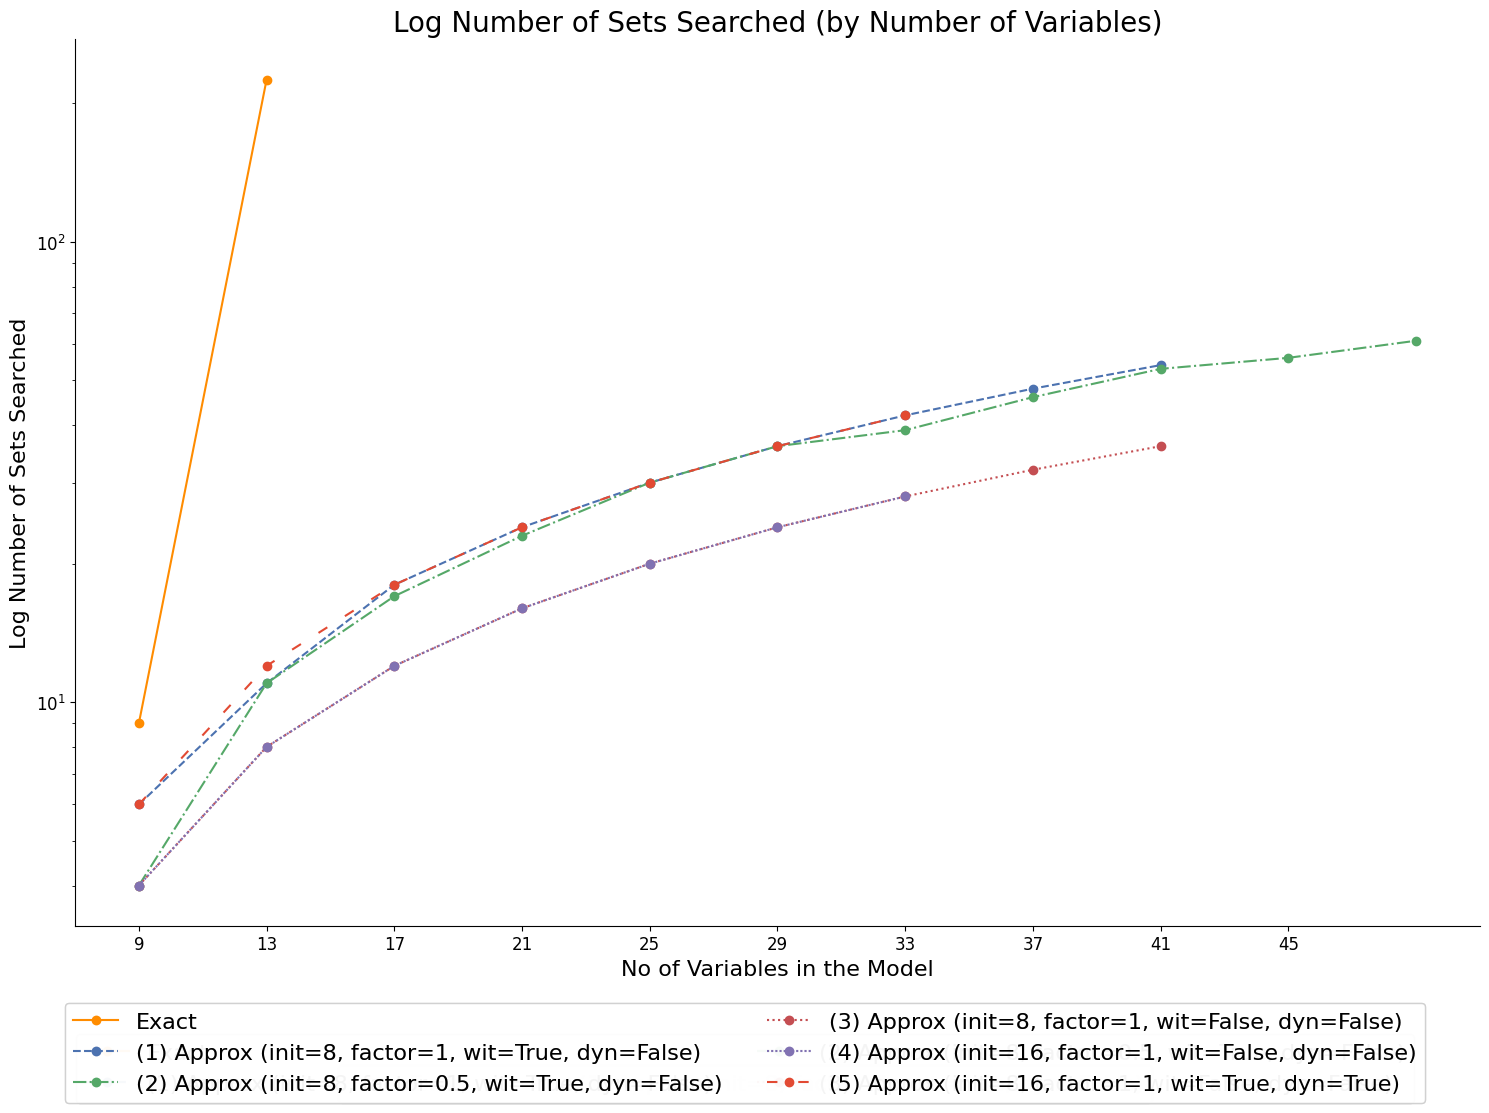

In [33]:
# ---------------------- PLOT 2 (updated, with exact data preserved) ----------------------
fig2, ax2 = plt.subplots(figsize=(15, 10))

ax2.set_title("Win Frequency Across Variable Set Sizes", fontsize=20)
ax2.set_xlabel("No of Variables in the Model", fontsize=16)
ax2.set_ylabel("Win Frequency", fontsize=16)

max_sites = 0


color = "darkorange"
ax2.plot(
    subsets_df.index, subsets_df["search_space"], marker="o", color=color, label="Exact"
)
ax2.set_title("Log Number of Sets Searched (by Number of Variables)", fontsize=20)
ax2.set_xlabel("No of Variables in the Model", fontsize=16)
ax2.set_ylabel("Log Number of Sets Searched", fontsize=16)

for idx, (approx_result, color, lty) in enumerate(
    zip(approximate_results_list, colors, line_styles), start=1
):
    df = approx_result["runtime_per_observation_approx_df"]
    y_vals = df.T.squeeze().values  # works for single-column/single-row frames
    x_vals = list(range(0, len(y_vals)))

    max_sites = max(max_sites, max(x_vals))

    size_parameters = list(range(1, max_sites + 2))
    numbers_of_variables = [str((4 * n) + 1) for n in size_parameters]

    for i in range(3):
        for tick in ax2.get_xticklabels():
            tick.set_fontsize(12)
        for tick in ax2.get_yticklabels():
            tick.set_fontsize(12)

        ax2.set_xticks(range(0, max_sites + 1))
        ax2.set_xticklabels(numbers_of_variables, fontsize=12)

    search_space_approx_df = approx_result["search_space_approx_df"]
    ax2.set_yscale("log")
    ax2.plot(
        search_space_approx_df.index,
        search_space_approx_df["search_space"],
        marker="o",
        linestyle=lty,
        color=color,
        label=f"({idx}) Approx (init={approx_result['run_params']['initial_num_search_samples']}, "
        f"factor={approx_result['run_params']['linear_sample_size_factor']}, "
        f"wit={approx_result['run_params']['use_witnesses']}, "
        f"dyn={approx_result['run_params']['dynamic_set_sizes']})",
    )

    fig2.legend(loc="lower center", ncol=2, fontsize=16, bbox_to_anchor=(0.5, -0.12))

sns.despine()
fig2.tight_layout()
fig2.savefig("ac_benchmark/plot2_search_space.png")
plt.show()

/tmp/ipykernel_36222/447869764.py:100: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig3.tight_layout()


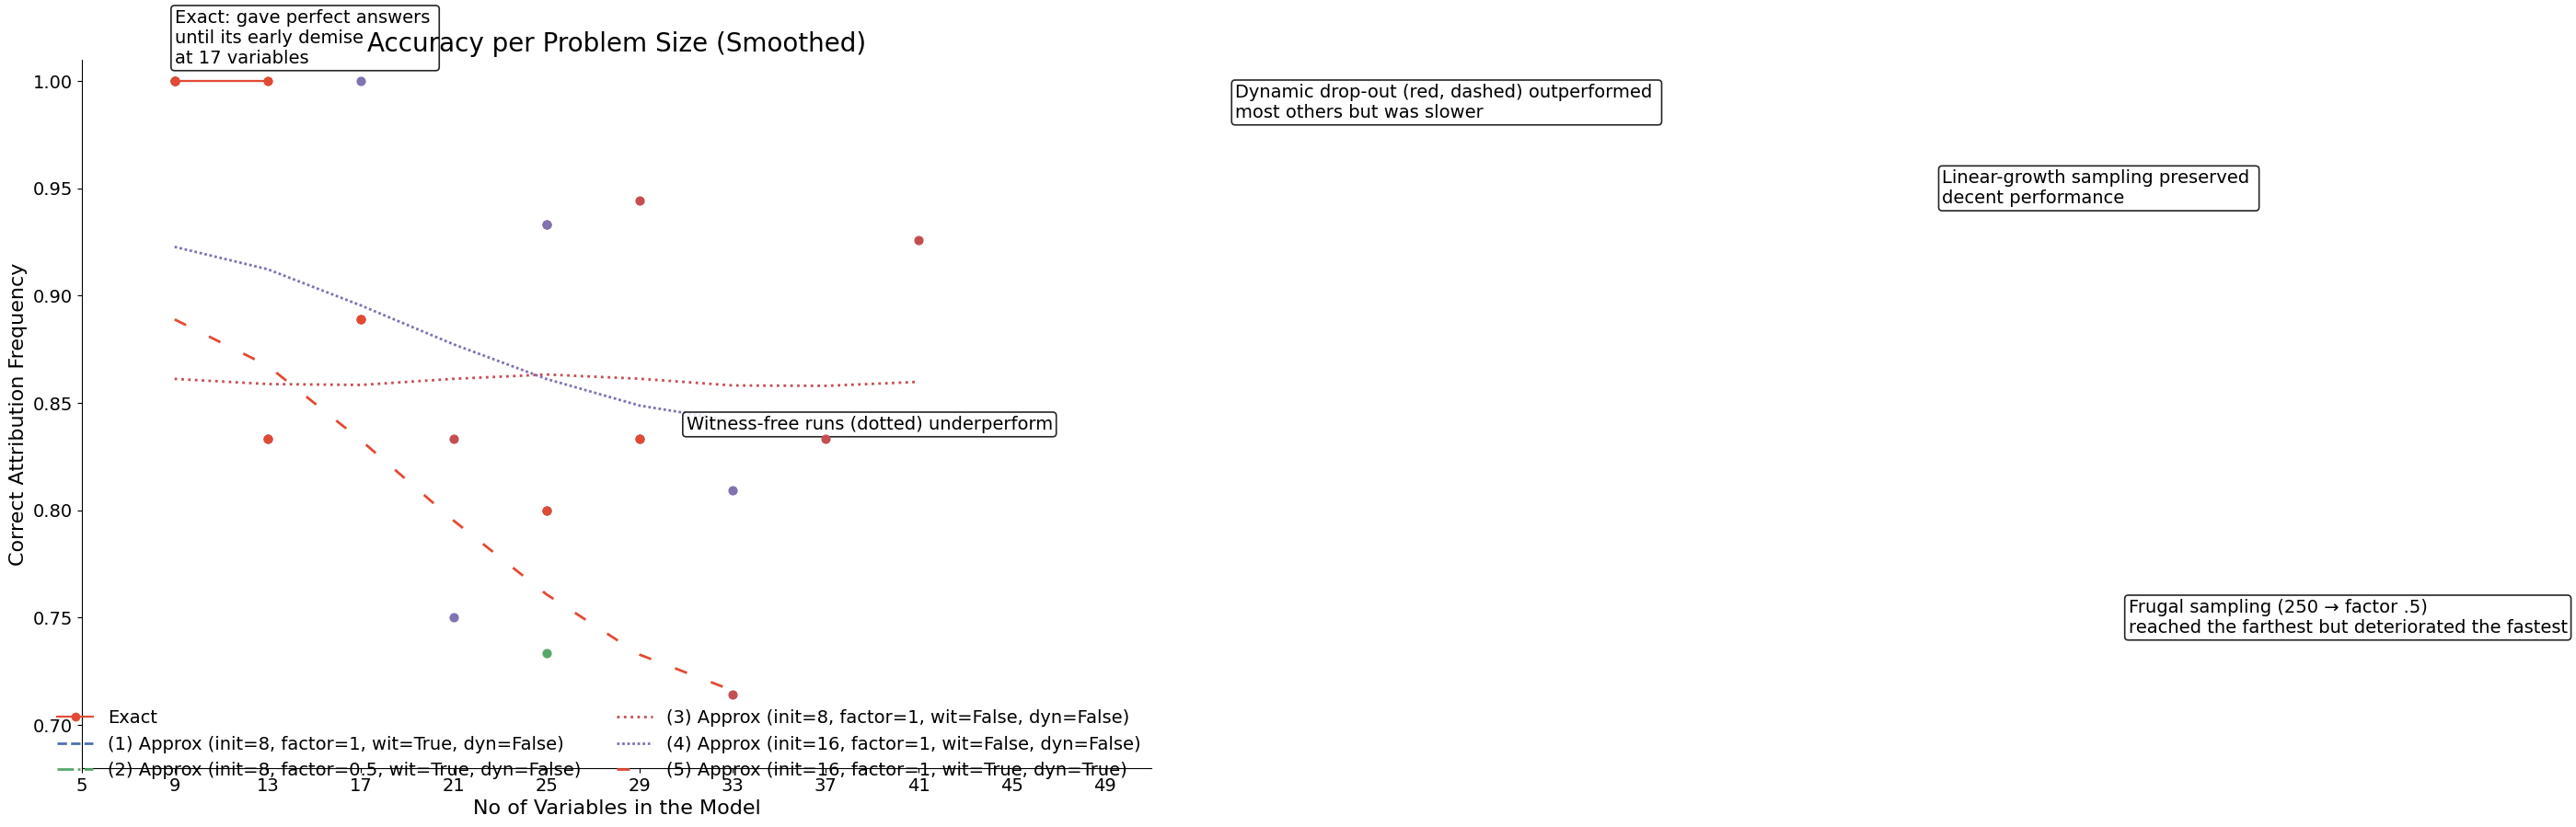

In [34]:
# ---------------------- PLOT 3 ----------------------
fig3, ax3 = plt.subplots(figsize=(15, 10))

ax3.set_title("Accuracy per Problem Size (Smoothed)", fontsize=20)
ax3.set_xlabel("No of Variables in the Model", fontsize=16)
ax3.set_ylabel("Correct Attribution Frequency", fontsize=16)

max_sites = 0


label = "Exact"
for col in win_freqs_df.columns:
    ax3.plot(
        win_freqs_df.index, win_freqs_df[col], marker="o", color=color, label=label
    )
    label = None  # only label first line to avoid duplicates in legend

# Track maximum x
max_sites = max(max_sites, win_freqs_df.index.max())


# -------- APPROXIMATE LINES -------------------------------
for idx, (approx_result, color, lty) in enumerate(
    zip(approximate_results_list, colors, line_styles), start=1
):
    y = approx_result["win_freqs_approx_df"].squeeze().values
    y = np.array(y, dtype=float)

    # Gaussian smoothing
    y_smooth = gaussian_filter1d(y, sigma=2.0)

    x_vals = approx_result["win_freqs_approx_df"].index.values
    max_sites = max(max_sites, max(x_vals))

    # Smoothed line
    ax3.plot(
        x_vals,
        y_smooth,
        linestyle=lty,
        linewidth=2,
        color=color,
        label=(
            f"({idx}) Approx (init={approx_result['run_params']['initial_num_search_samples']}, "
            f"factor={approx_result['run_params']['linear_sample_size_factor']}, "
            f"wit={approx_result['run_params']['use_witnesses']}, "
            f"dyn={approx_result['run_params']['dynamic_set_sizes']})"
        ),
    )

    # Raw scatter
    ax3.scatter(x_vals, y, s=40, color=color, zorder=5)


# -------- X-TICKS (same as other figs) ---------------------
size_parameters = list(range(1, max_sites + 2))
numbers_of_variables = [str((4 * n) + 1) for n in size_parameters]

ax3.set_xticks(range(0, max_sites + 1))
ax3.set_xticklabels(numbers_of_variables, fontsize=14)
ax3.tick_params(axis="both", labelsize=14)

# -------- Y LIMITS ----------------------------------------
ax3.set_ylim(0.68, 1.01)

# -------- ANNOTATIONS -------------------------------------
add_line_end_label(
    ax3,
    1,
    1.02,
    "Exact: gave perfect answers \nuntil its early demise \nat 17 variables",
)

add_line_end_label(
    ax3,
    12.4,
    .99,
    "Dynamic drop-out (red, dashed) outperformed \nmost others but was slower",
)

add_line_end_label(
    ax3,
    22,
    0.75,
    "Frugal sampling (250 → factor .5)\nreached the farthest but deteriorated the fastest",
)

add_line_end_label(
    ax3, 20, .95, "Linear-growth sampling preserved \ndecent performance"
)

add_line_end_label(ax3, 6.5, 0.84, "Witness-free runs (dotted) underperform")


fig3.legend(
    loc="lower center", bbox_to_anchor=(0.5, 0.08), ncol=2, frameon=False, fontsize=14
)


sns.despine()
fig3.tight_layout()
fig3.savefig("ac_benchmark/plot3_accuracy.png")
plt.show()

In [35]:
# SAME, three plots in one figure
# if we decide to use this

# fig, axes = plt.subplots(3, 1, figsize=(15, 30))

# axes[0].set_title("Runtime per Single World", fontsize=20)
# axes[0].set_xlabel("No of Variables in the Model", fontsize=16)
# axes[0].set_ylabel("Runtime (s)", fontsize=16)


# # Scatter exact
# for col in df_melted["Column"].unique():
#     subset = df_melted[df_melted["Column"] == col]
#     x_vals = [col] * len(subset)
#     axes[0].scatter(x_vals, subset["Runtime"], s=20, alpha=0.7, color="darkorange")


# axes[0].plot(
#     mean_vals["Column"],
#     mean_vals["Runtime"],
#     marker="o",
#     linestyle="-",
#     linewidth=2,
#     markersize=6,
#     color="darkorange",
#     label="Exact (mean per world)",
# )

# max_sites = int(mean_vals["Column"].max())


# size_parameters = list(range(1, max_sites + 2))
# numbers_of_variables = [str((4 * n)+1) for n in size_parameters]

# for idx, (approx_result, color, lty) in enumerate(zip(approximate_results_list, colors, line_styles), start=1):


#     df = approx_result["runtime_per_observation_approx_df"]
#     y_vals = df.T.squeeze().values  # works for single-column/single-row frames
#     x_vals = list(range(0, len(y_vals)))

#     axes[0].plot(
#         x_vals,
#         y_vals,
#         marker="o",
#         linestyle=lty,
#         linewidth=2,
#         markersize=6,
#         label=(
#             f"({idx}) Approx (initial samples: {approx_result['run_params']['initial_num_search_samples']}, "
#             f"factor: {approx_result['run_params']['linear_sample_size_factor']}, "
#             f"witnesses: {approx_result['run_params']['use_witnesses']}, "
#             f"dynamic: {approx_result['run_params']['dynamic_set_sizes']})"
#         ),
#         color=color,
#     )

#     max_sites = max(max_sites, max(x_vals))

#     search_space_approx_df = approx_result["search_space_approx_df"]
#     axes[1].set_yscale("log")
#     axes[1].plot(
#         search_space_approx_df.index,
#         search_space_approx_df["search_space"],
#         marker="o",
#         linestyle=lty,
#         color=color,
#     )

#     # axes[2].plot(
#     #     approx_result["win_freqs_approx_df"].index,
#     #     approx_result["win_freqs_approx_df"].squeeze(),
#     #     marker="o",
#     #     linestyle=lty,
#     #     color=color,
#     # )


#     y = approx_result["win_freqs_approx_df"].squeeze().values
#     y = np.array(y, dtype=float)  # <- force numeric

#     # Now smoothing works
#     y_smooth = gaussian_filter1d(y, sigma=2.0)

#     x_vals = approx_result["win_freqs_approx_df"].index.values

#     # Plot smoothed line
#     axes[2].plot(
#         x_vals,
#         y_smooth,
#         linestyle=lty,
#         color=color,
#         linewidth=2,
#     )

#     # Plot original points on top
#     axes[2].scatter(
#         x_vals,
#         y,
#         color=color,
#         s=40,
#         zorder=5
#     )


# # set ticks

# size_parameters = list(range(1, max_sites + 2))
# numbers_of_variables = [str((4 * n)+1) for n in size_parameters]

# for i in range(3):
#     for tick in axes[i].get_xticklabels():
#         tick.set_fontsize(12)
#     for tick in axes[i].get_yticklabels():
#         tick.set_fontsize(12)

#     axes[i].set_xticks(range(0, max_sites + 1))
#     axes[i].set_xticklabels(numbers_of_variables, fontsize=12)


# fig.legend(
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.04),   # move legend above the top
#     ncol=2,
#     frameon=False,
#     fontsize=16,
# )

# add_line_end_label(
#     axes[0],
#     3.5 ,
#     40,
#     text="Exact: timed out at 17 vars \nwith search space > 65k",
# )

# add_line_end_label(
#     axes[0],
#     18,
#     60,
#     text="Approximate methods with initial samples 500 \nand factor=1  timed out at$ \\approx70$ vars",
# )

# add_line_end_label(
#     axes[0],
#     23,
#     40,
#     text="Approximate methods with initial samples 250 \nand factor=1  timed out at$ \\approx105$ vars",
# )


# add_line_end_label(
#     axes[0],
#     23,
#     10,
#     text="Approximate method with initial samples 250 \nand factor=.5  timed out at  $\\approx150$ vars",
# )


# color = "darkorange"
# axes[1].plot(subsets_df.index, subsets_df["search_space"], marker="o", color=color)
# axes[1].set_title("Log Number of Sets Searched (by Number of Variables)", fontsize=20)
# axes[1].set_xlabel("No of Variables in the Model", fontsize = 16)
# axes[1].set_ylabel("Log Number of Sets Searched", fontsize=16)


# add_line_end_label(
#     axes[1],
#     4.5,
#     10**4.5,
#     text="Exact: powerset explosion",
# )

# add_line_end_label(
#     axes[1],
#     16,
#     10**2.5,
#     text="Approximate methods: \nlinear growth in sets searched",
# )


# for col in win_freqs_df.columns:
#     axes[2].plot(win_freqs_df.index, win_freqs_df[col], marker="o", color=color)

# axes[2].set_title("Accuracy per Problem Size  (Smoothed)", fontsize=20)
# axes[2].set_xlabel("No of Variables in the Model", fontsize=16)
# axes[2].set_ylabel("Correct Attribution Frequency", fontsize=16)

# axes[2].set_ylim(0, 1.2)


# add_line_end_label(
#     axes[2],
#     4.6,
#     1.07,
#     text="Exact: gave perfect answers \nuntil its early demise \nat 17 variables in the model",
# )


# add_line_end_label(
#     axes[2],
#     8,
#     .7,
#     text="Dynamic drop-out (red, dashed) outperformed \nmost of other settings  but was slower"
#     )


# add_line_end_label(
#     axes[2],
#     22,
#     .7,
#     text="Frugal sampling (start at 250, factor 0.5)\nreached the farthest but deteriorated the fastest"
# )


# add_line_end_label(
#     axes[2],
#     19,
#     1.02,
#     text="Sensible linear growth sampling schema \npreserved decent performance"
# )


# add_line_end_label(
#     axes[2],
#     3,
#     .79,
#     text="Witness-free runs (dotted) underperform"
# )


# plt.tight_layout()
# sns.despine()
# plt.suptitle("Responsibility Attribution Benchmarking Results (60 minutes per setting)", fontsize=26, y=1.05)

# plt.savefig("actual_causality_benchmark.png")

# plt.show()